# Context CD axis

This notebook builds a coding-direction (CD) axis from **high right-choice-probability** vs **high left-choice-probability** trials, using the sliding-window choice-probability trial types now produced by `generate_behavior_summary`.

Idea: the per-trial sliding-window P(right) reflects the animal's recent choice *bias* â€” i.e. the running context â€” rather than the action on the current trial. A CD axis fit on `right_choice_probability_bigger_{thr}` vs `left_choice_probability_bigger_{thr}` therefore captures **context encoding**, and can be compared with the standard choice-CD (right_choice vs left_choice on the current trial) to dissociate context vs choice encoding.

Trial-type columns expected in the behavior CSV (added in `behavior_utils.generate_behavior_summary`):

- `right_choice_probability_bigger_{thr}_windowsize_{N}_trials` â†’ trials whose sliding P(right) > thr
- `left_choice_probability_bigger_{thr}_windowsize_{N}_trials`  â†’ trials whose sliding P(left)  > thr  (equivalently P(right) < 1-thr)

In [2]:
# =============================================================================
# 1. ENVIRONMENT SETUP & MODULE IMPORTS
# =============================================================================
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

MODULE_PATH = Path("/root/capsule/src/aind_dft_ephys_analysis")
if str(MODULE_PATH) not in sys.path:
    sys.path.insert(0, str(MODULE_PATH))

print(f"âœ… Analysis modules loaded from: {MODULE_PATH}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
âœ… Analysis modules loaded from: /root/capsule/src/aind_dft_ephys_analysis


In [3]:
# ALM recordings â€” sessions of interest
sessions = [
    "ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38",
    "ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35",
    "ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43",
    "ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45",
    "ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51",
    "ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13",
]

## Configure the context trial types

Choose the sliding-window threshold and window size that define "high P(right)" and "high P(left)" contexts. These must match entries produced by `generate_behavior_summary` (default windows: 5,10,15,20,30; default thresholds: 0.5,0.6,0.7,0.8,0.9).

In [4]:
# Context defining parameters
cp_threshold   = 0.8    # high-P(side) cutoff (strict >)
cp_windowsize  = 10     # sliding window length (responded trials only)

context_right = f"right_choice_probability_bigger_{cp_threshold}_windowsize_{cp_windowsize}_trials"
context_left  = f"left_choice_probability_bigger_{cp_threshold}_windowsize_{cp_windowsize}_trials"
context_trial_types = (context_right, context_left)

print("A (right-context):", context_right)
print("B (left-context) :", context_left)

A (right-context): right_choice_probability_bigger_0.8_windowsize_10_trials
B (left-context) : left_choice_probability_bigger_0.8_windowsize_10_trials


In [53]:
# =============================================================================
# Build CONTEXT-CD zarrs (high P(right) vs high P(left) trials)
# =============================================================================
from pathlib import Path
from ephys_dimension_reduction_CD_pipeline import build_cd_dataset

psth_root     = Path("/root/capsule/scratch/psth_results")
behavior_root = Path("/root/capsule/scratch/behavior_summary")
cd_root       = Path("/root/capsule/scratch/CD_results")

align                  = "trial_start"
binsize                = "0.1"
brain_regions_groups   = [[]]              # [[]] => all units
time_windows           = [(1, 2)]          # CD-fitting window (pre-go_cue)
min_units_num          = 30
projection_time_window = None
two_fold_cv            = True
norm_mode              = "divide_sqrtN"
random_state           = 0
overwrite              = True

failed = build_cd_dataset(
    sessions=sessions,
    psth_root=psth_root,
    behavior_root=behavior_root,
    cd_root=cd_root,
    metadata=None,
    binsize=binsize,
    align=align,
    brain_regions_groups=brain_regions_groups,
    time_windows=time_windows,
    trial_types=context_trial_types,
    min_units_num=min_units_num,
    projection_time_window=projection_time_window,
    two_fold_cv=two_fold_cv,
    norm_mode=norm_mode,
    random_state=random_state,
    overwrite=overwrite,
)
print("Failed sessions:", failed)


Session: ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38
  Region RG_ALL (ALL): ALL units
    ✔ Finished time window (1, 2): /root/capsule/scratch/CD_results/CD_ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38_RG_ALL_right_choice_probability_bigger_0.8_windowsize_10_trials_left_choice_probability_bigger_0.8_windowsize_10_trials_TW_1_2_ALIGN_trial_start.zarr

Session: ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35
  Region RG_ALL (ALL): ALL units
    ✔ Finished time window (1, 2): /root/capsule/scratch/CD_results/CD_ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35_RG_ALL_right_choice_probability_bigger_0.8_windowsize_10_trials_left_choice_probability_bigger_0.8_windowsize_10_trials_TW_1_2_ALIGN_trial_start.zarr

Session: ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43
  Region RG_ALL (ALL): ALL units
    ✔ Finished time window (1, 2): /root/capsule/scratch/CD_results/CD_ecephys_844034_2026-05-07_12-26-08_sorted_2026-0

## Visualize the context-CD per session

Context CD | region=RG_ALL (ALL) | TW=(1, 2) | align=trial_start

=== Session: ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38 ===
File: CD_ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38_RG_ALL_right_choice_probability_bigger_0.8_windowsize_10_trials_left_choice_probability_bigger_0.8_windowsize_10_trials_TW_1_2_ALIGN_trial_start.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


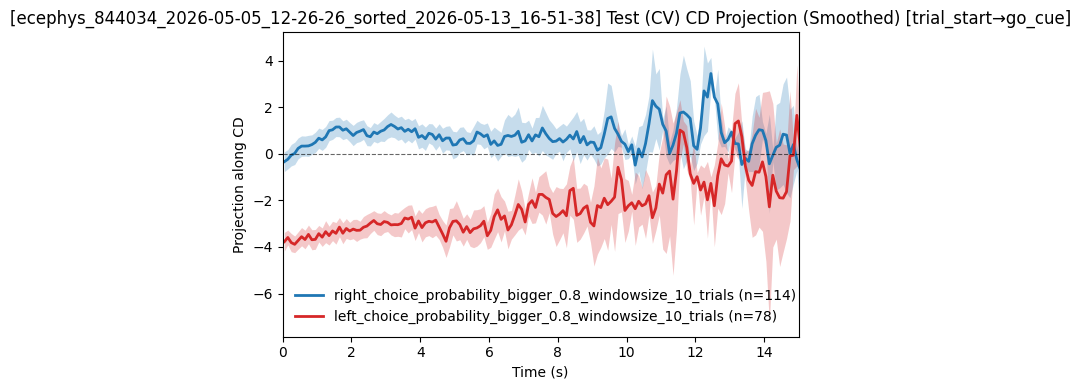

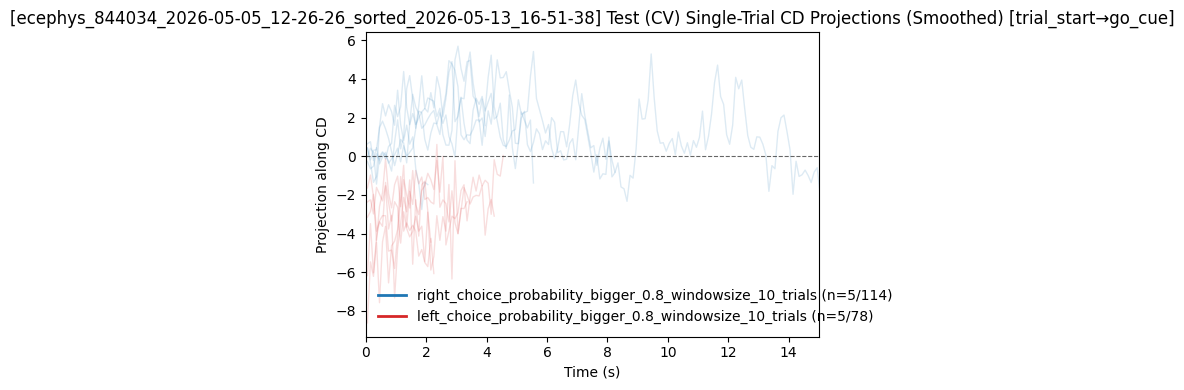

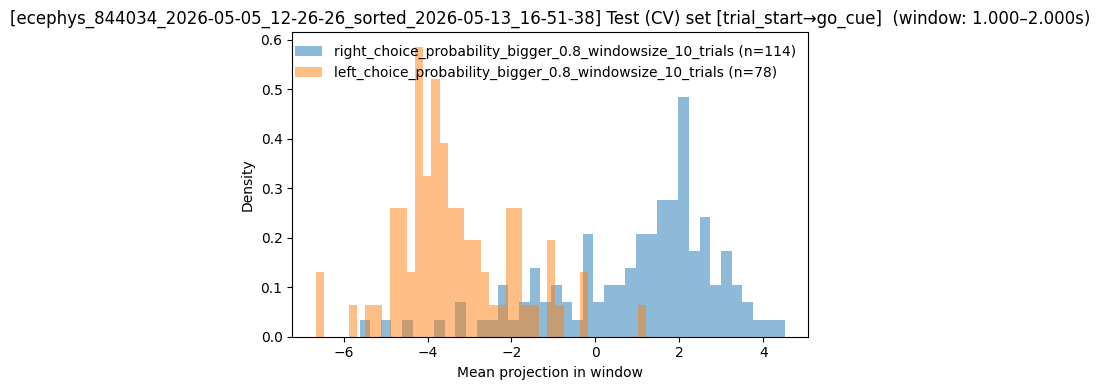


=== Session: ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35 ===
File: CD_ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35_RG_ALL_right_choice_probability_bigger_0.8_windowsize_10_trials_left_choice_probability_bigger_0.8_windowsize_10_trials_TW_1_2_ALIGN_trial_start.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


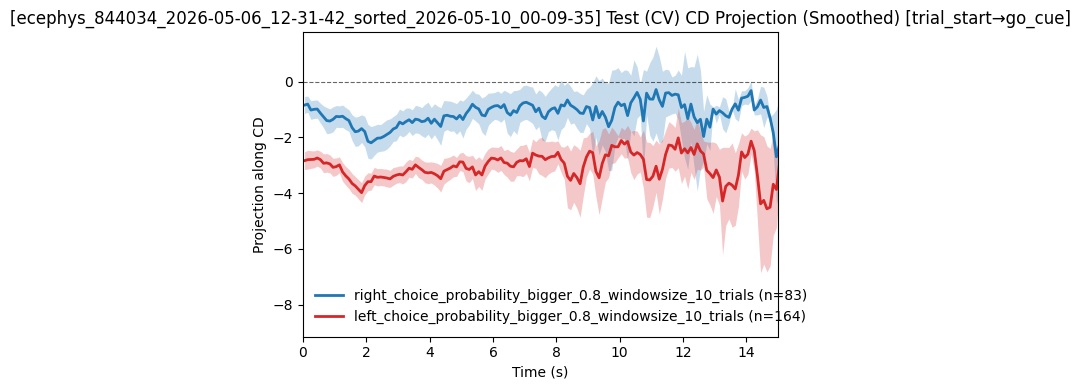

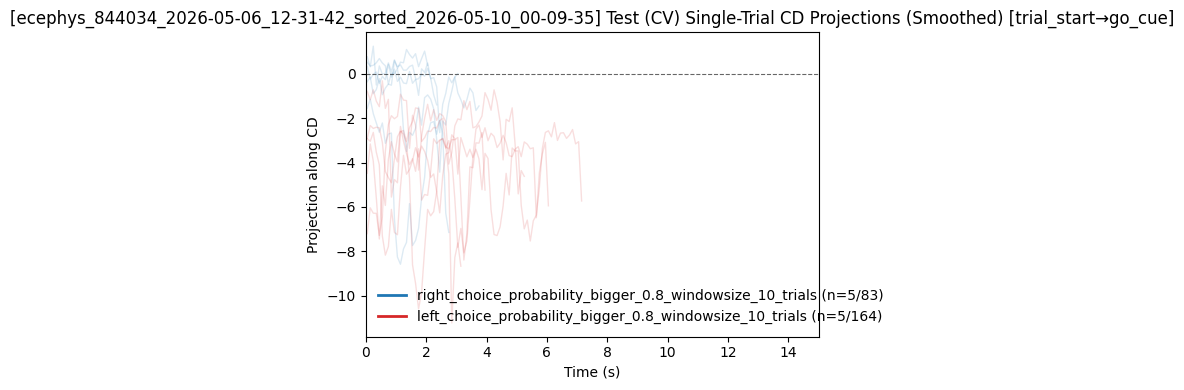

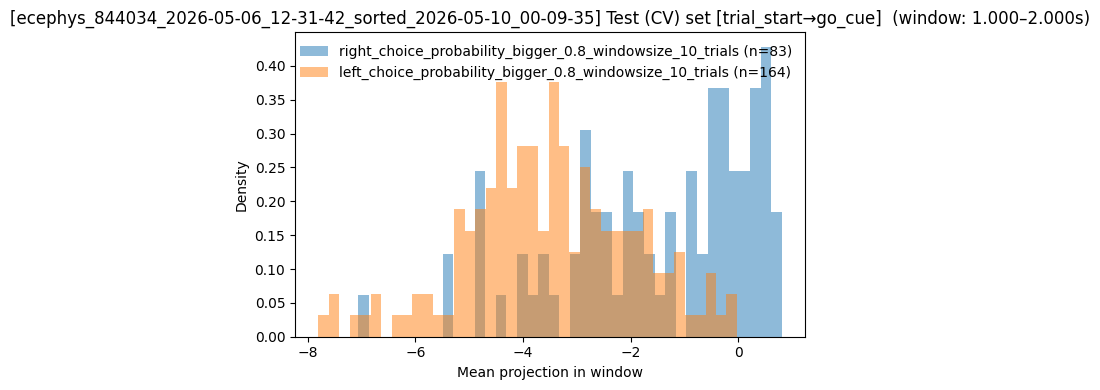


=== Session: ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43 ===
File: CD_ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43_RG_ALL_right_choice_probability_bigger_0.8_windowsize_10_trials_left_choice_probability_bigger_0.8_windowsize_10_trials_TW_1_2_ALIGN_trial_start.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


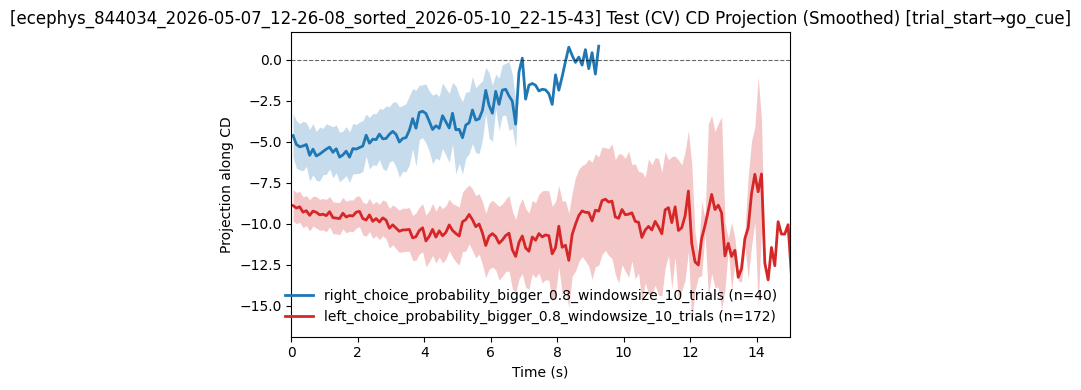

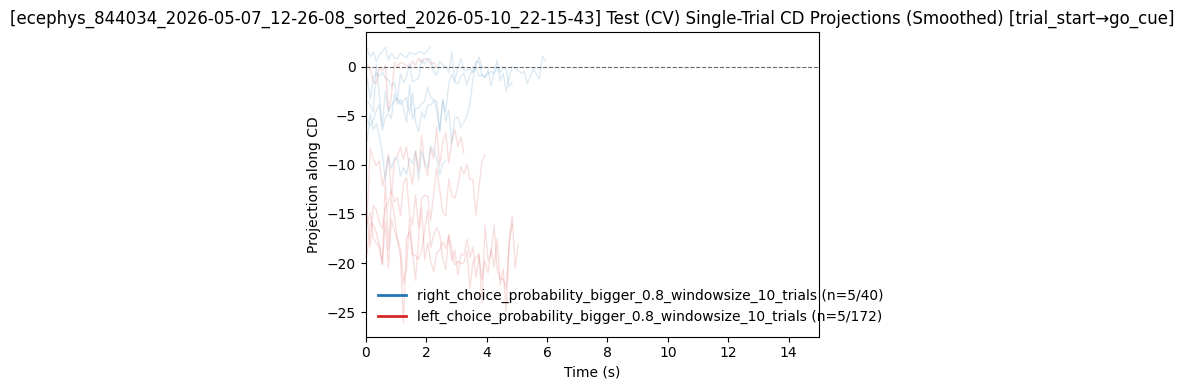

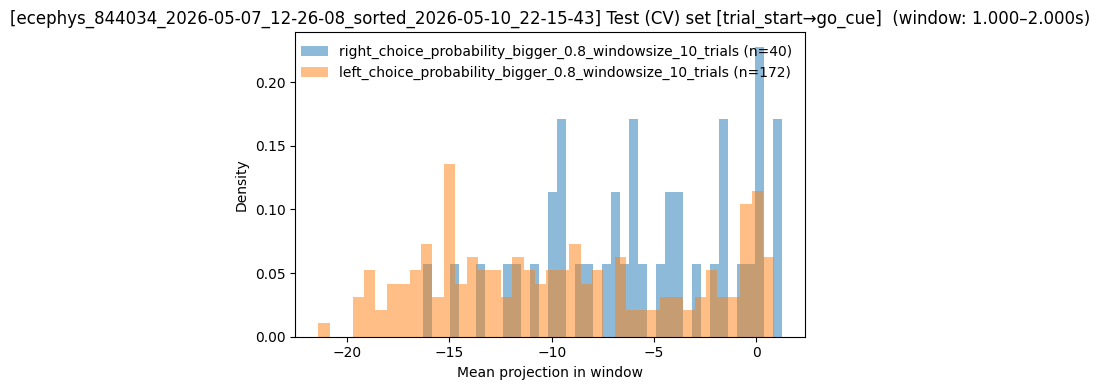


=== Session: ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45 ===
File: CD_ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45_RG_ALL_right_choice_probability_bigger_0.8_windowsize_10_trials_left_choice_probability_bigger_0.8_windowsize_10_trials_TW_1_2_ALIGN_trial_start.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


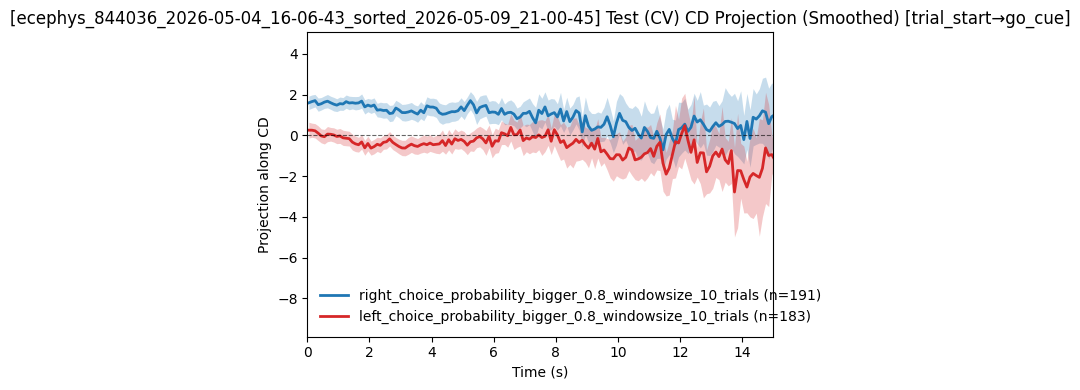

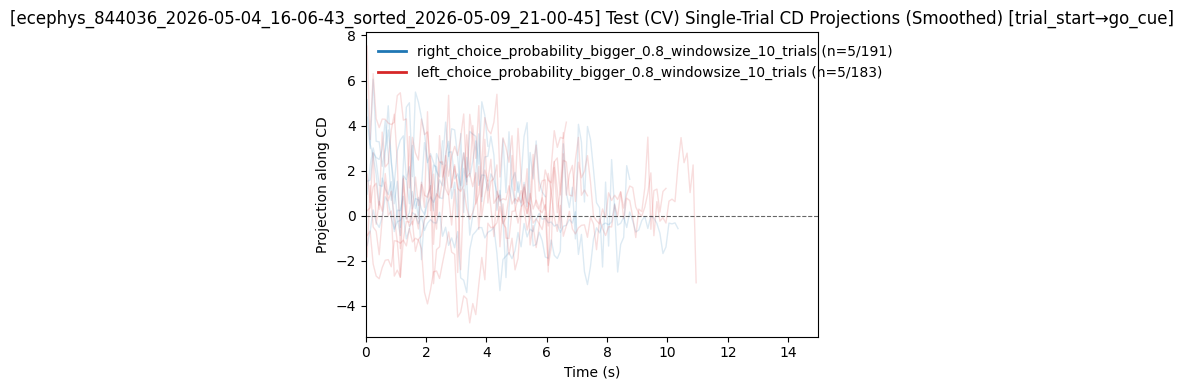

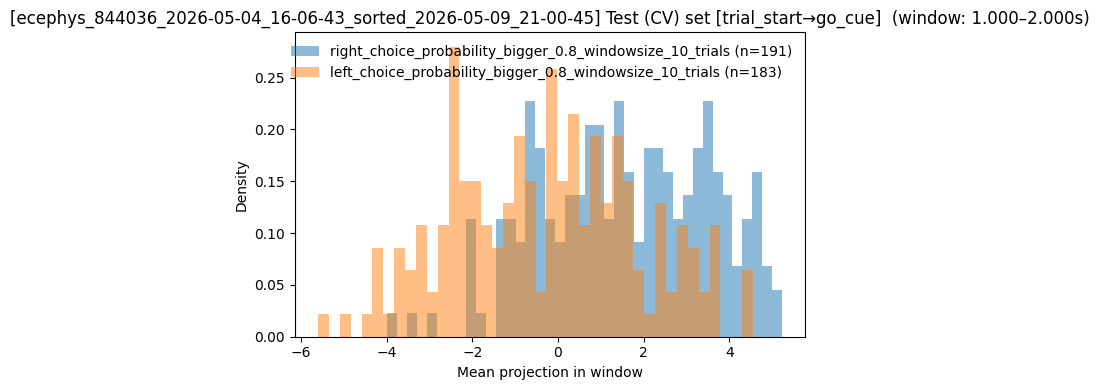


=== Session: ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51 ===
File: CD_ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51_RG_ALL_right_choice_probability_bigger_0.8_windowsize_10_trials_left_choice_probability_bigger_0.8_windowsize_10_trials_TW_1_2_ALIGN_trial_start.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


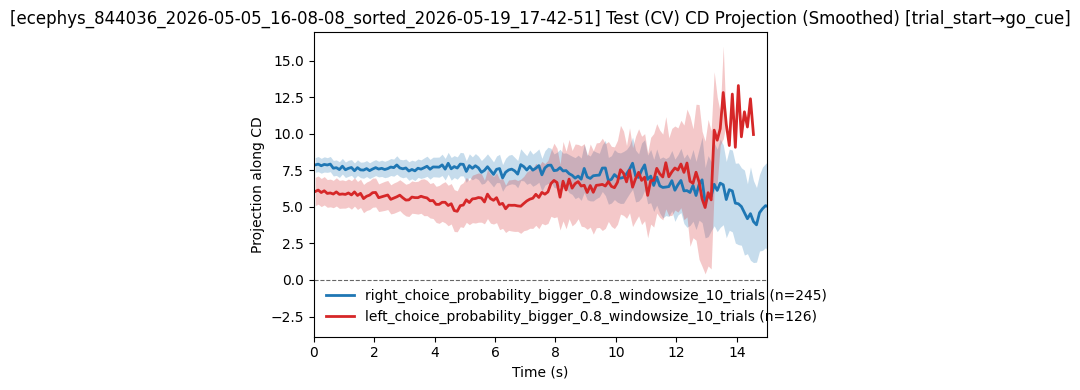

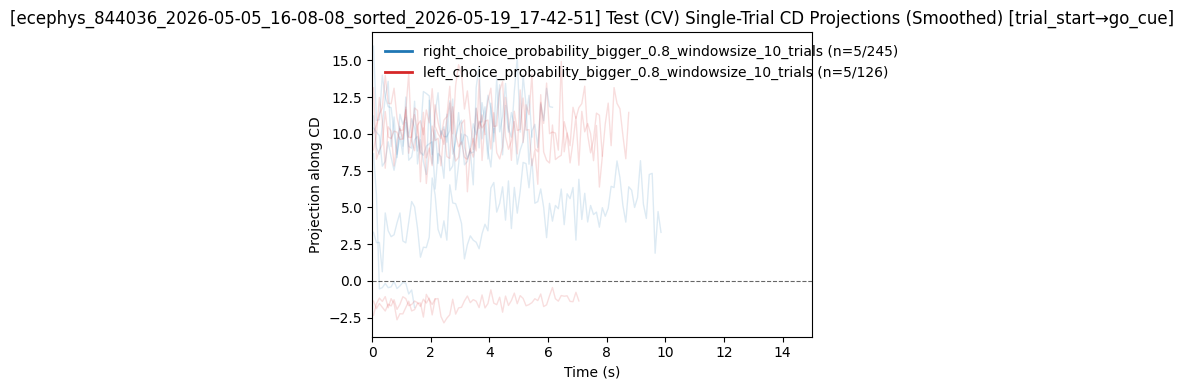

/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:75: RuntimeWarning: Mean of empty slice
  means = np.nanmean(sub, axis=1)


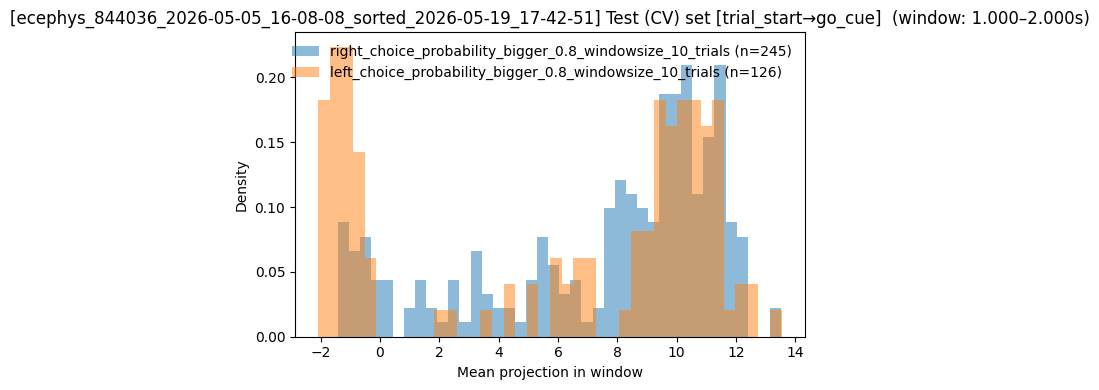


=== Session: ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13 ===
File: CD_ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13_RG_ALL_right_choice_probability_bigger_0.8_windowsize_10_trials_left_choice_probability_bigger_0.8_windowsize_10_trials_TW_1_2_ALIGN_trial_start.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


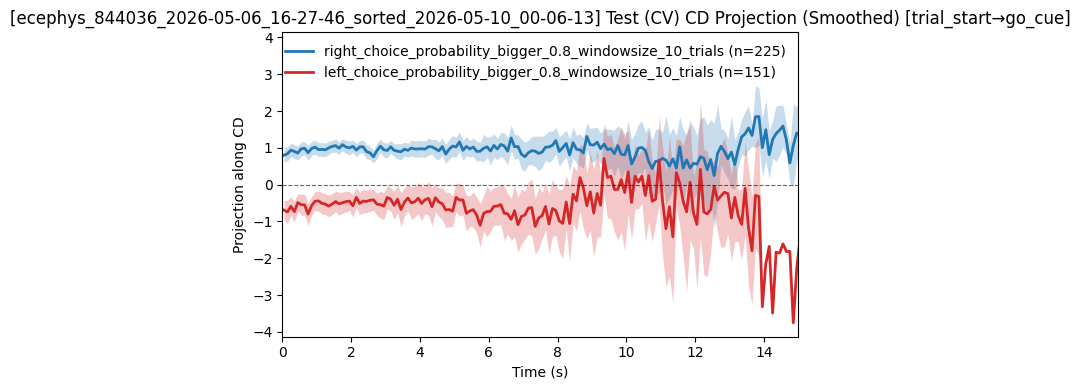

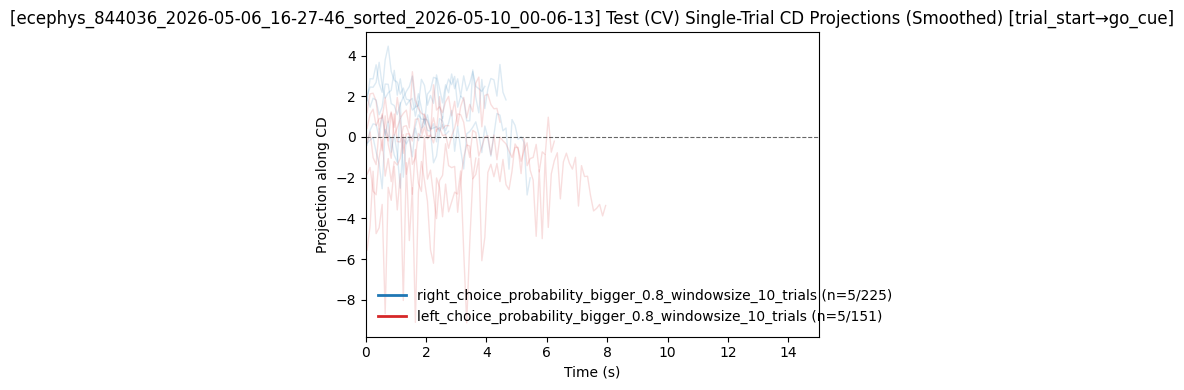

/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:75: RuntimeWarning: Mean of empty slice
  means = np.nanmean(sub, axis=1)


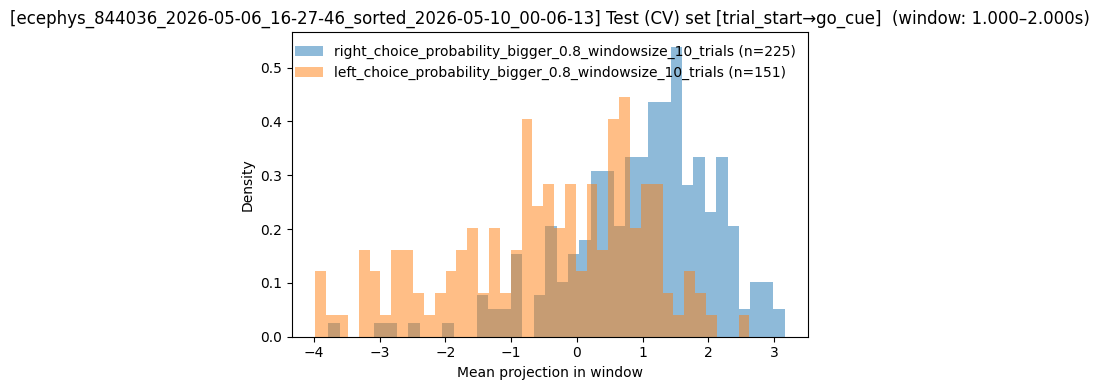

In [66]:
import os
from ephys_dimension_reduction_CD_pipeline import (
    cd_save_path, load_cd_session, plot_cd_session, region_label,
)

viz_region_group     = []
viz_time_window      = (1, 2)
distribution_window  = (1, 2)
restrict_events      = ("trial_start", "go_cue")

region_lbl, region_print = region_label(viz_region_group)
print(f"Context CD | region={region_lbl} ({region_print}) | TW={viz_time_window} | align={align}")

for session in sessions:
    zpath = cd_save_path(
        cd_root, session, region_lbl, context_trial_types, viz_time_window, align=align,
    )
    beh_csv = os.path.join(behavior_root, f"behavior_summary-{session}.csv")
    if not zpath.exists():
        print(f"[skip] CD zarr not found: {zpath}")
        continue
    if not os.path.exists(beh_csv):
        print(f"[skip] behavior CSV not found for {session}")
        continue

    print(f"\n=== Session: {session} ===\nFile: {zpath.name}")
    sess = load_cd_session(zpath, beh_csv)
    plot_cd_session(
        sess,
        distribution_window=distribution_window,
        restrict_events=restrict_events,
        restrict_align=align,
        xlim=(0, 15),
        split="test",
        smooth_gauss=0.0,
        smooth_moving_window=10,
        plot_single_trial=True,
        random_sample_trial_N=5,
    )

## Compare context-CD to choice-CD

Project trials defined by the **current-trial choice** (right_choice vs left_choice) onto the context CD axis. If the two axes overlap, the population is encoding choice rather than context; if context separates classes that choice does not (or vice versa), the dimensions are at least partially distinct.

In [65]:
align

'trial_start'


=== ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38: context-CD projected onto choice classes ===
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


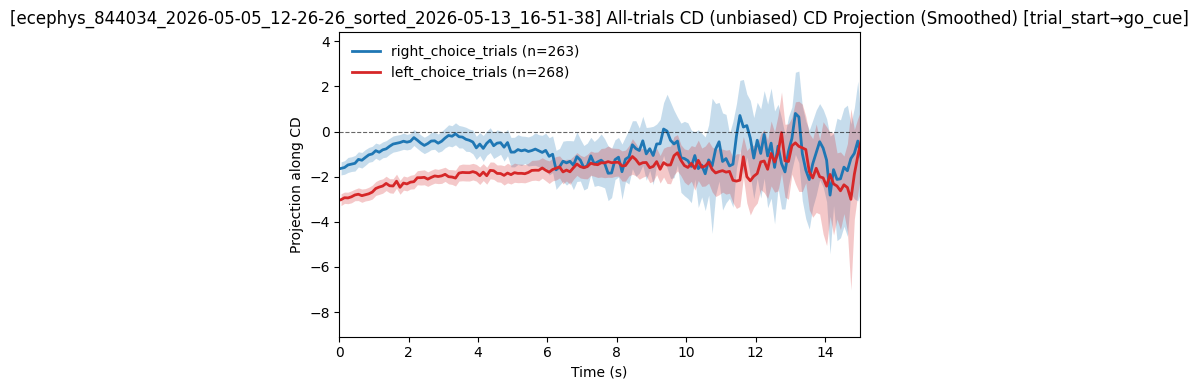

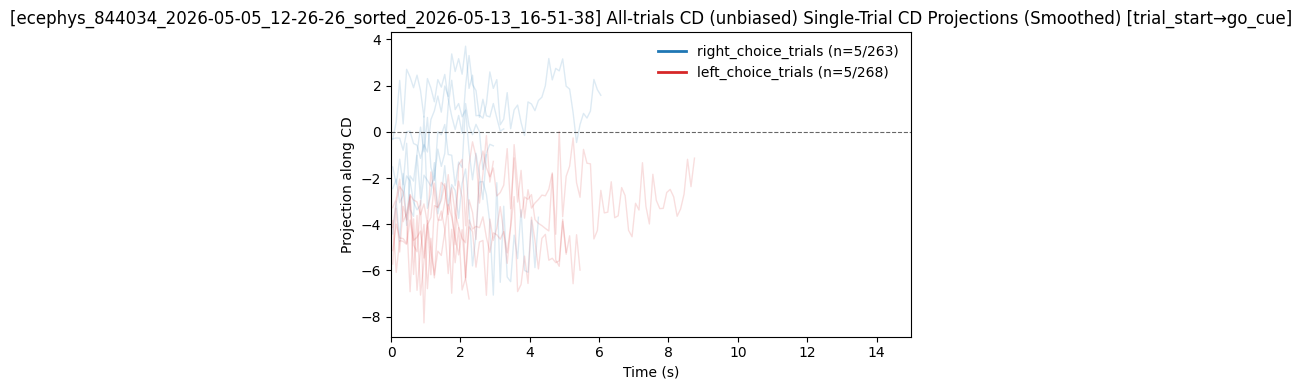

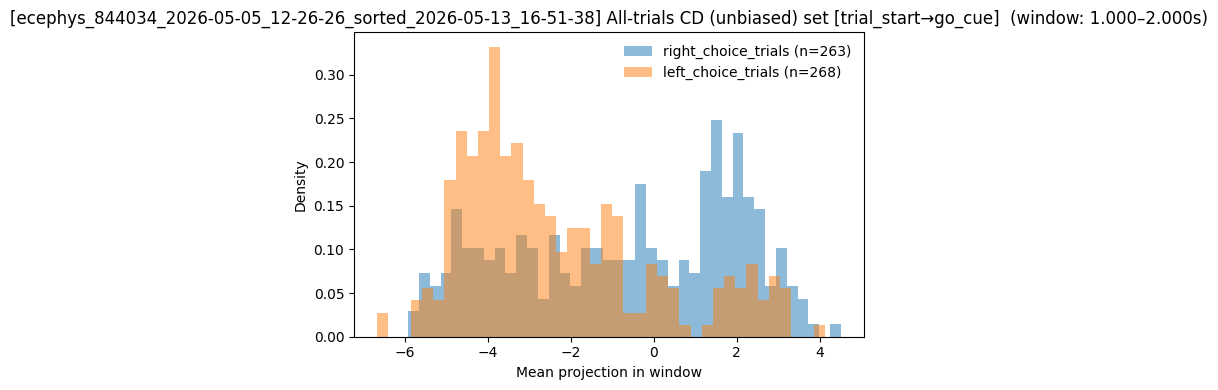


=== ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35: context-CD projected onto choice classes ===
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


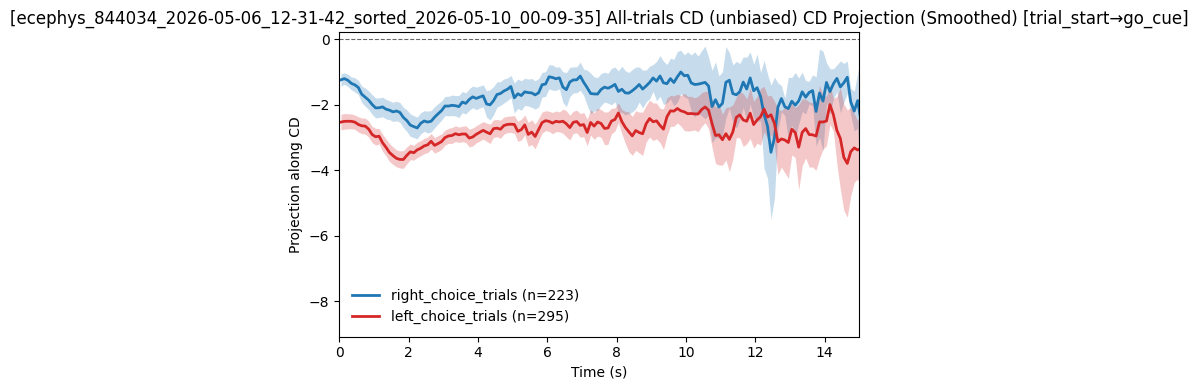

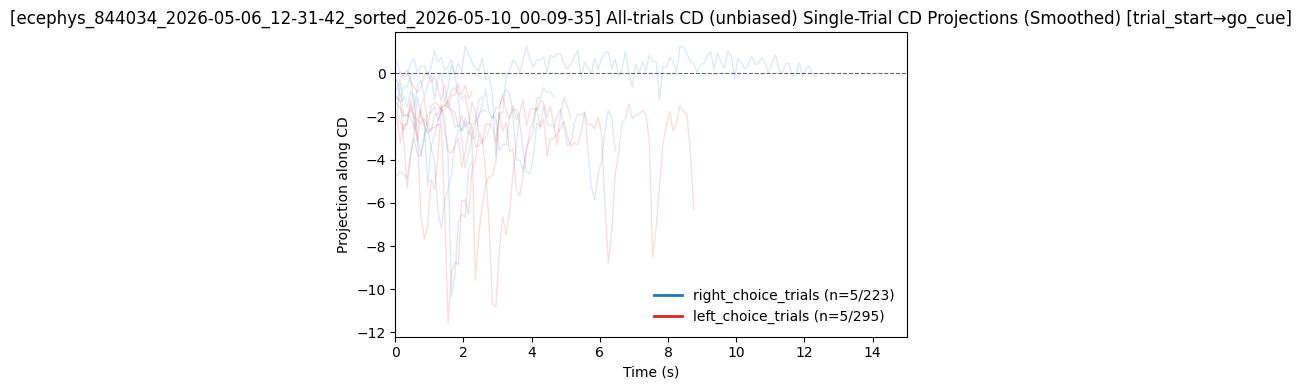

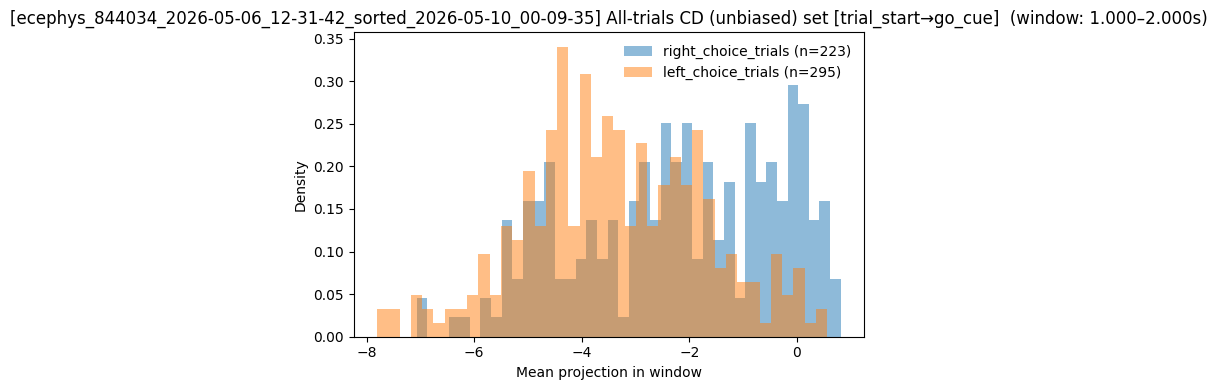


=== ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43: context-CD projected onto choice classes ===
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


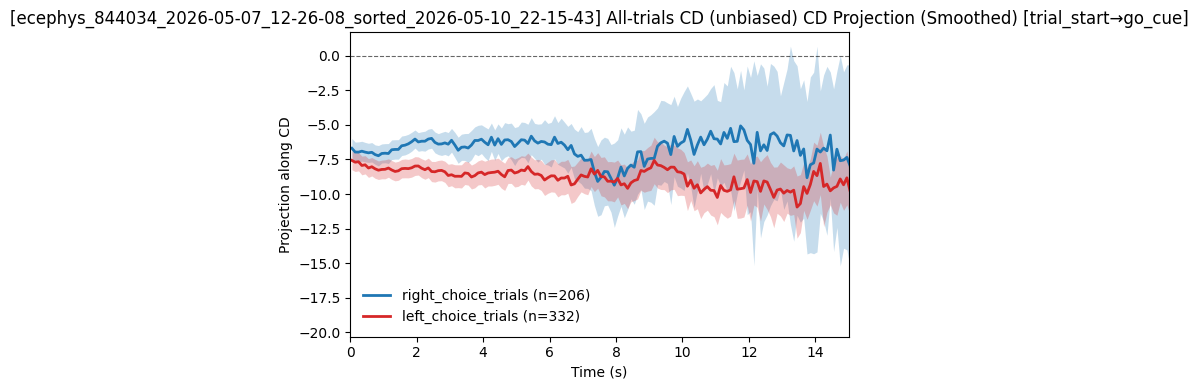

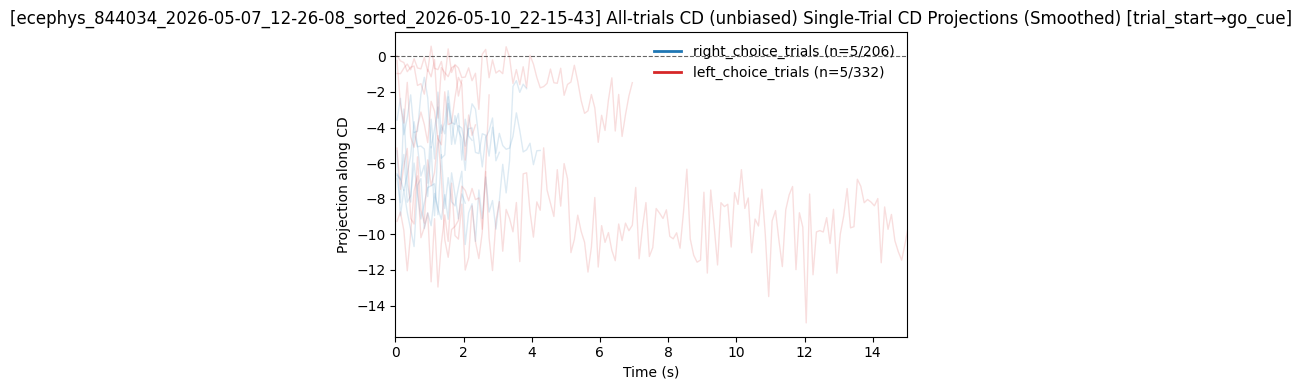

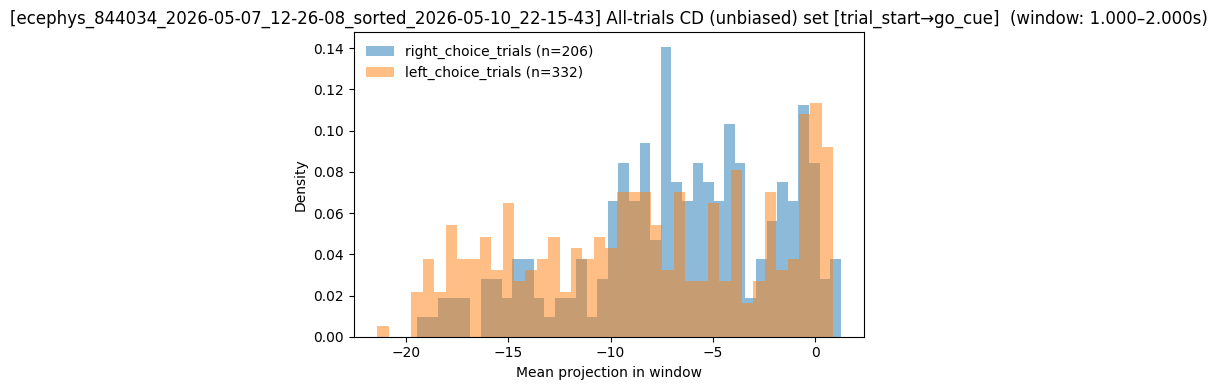


=== ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45: context-CD projected onto choice classes ===
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


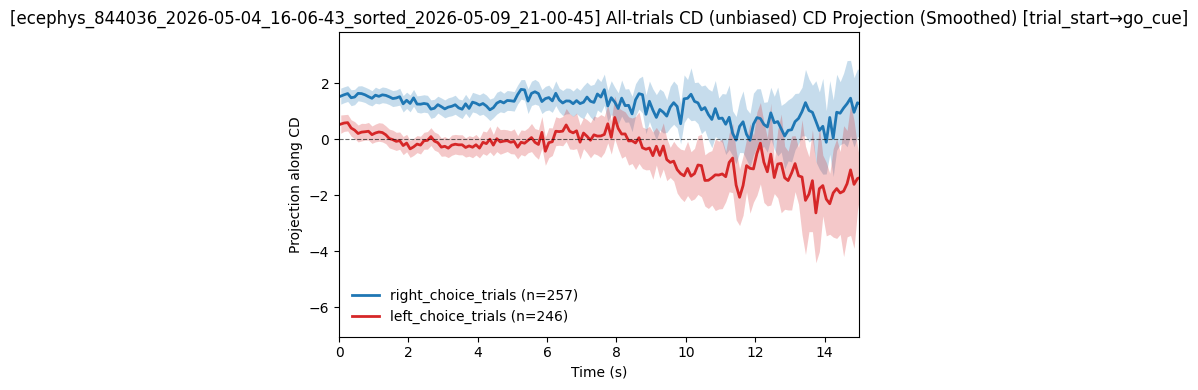

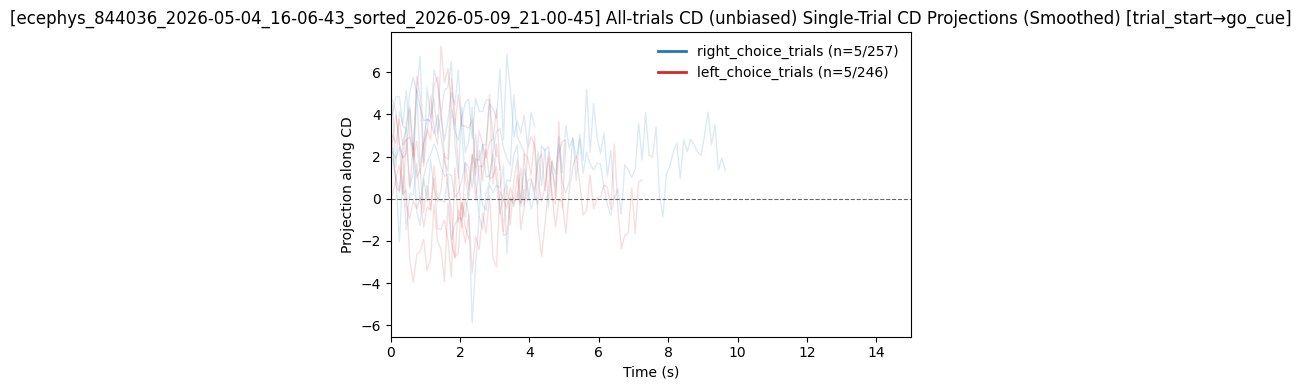

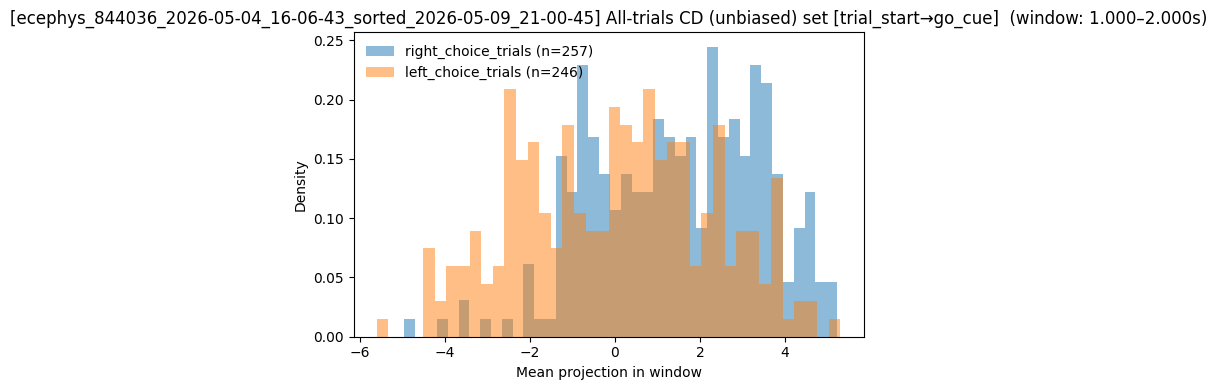


=== ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51: context-CD projected onto choice classes ===
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


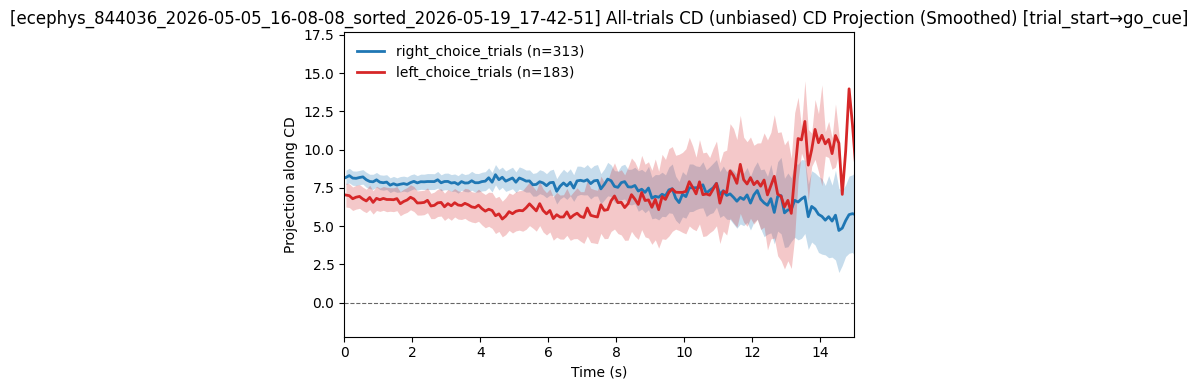

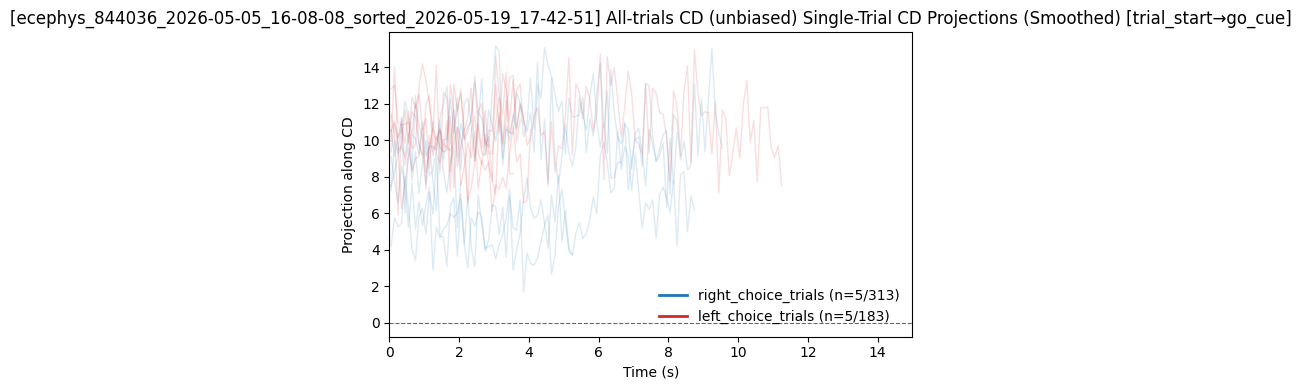

/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:75: RuntimeWarning: Mean of empty slice
  means = np.nanmean(sub, axis=1)


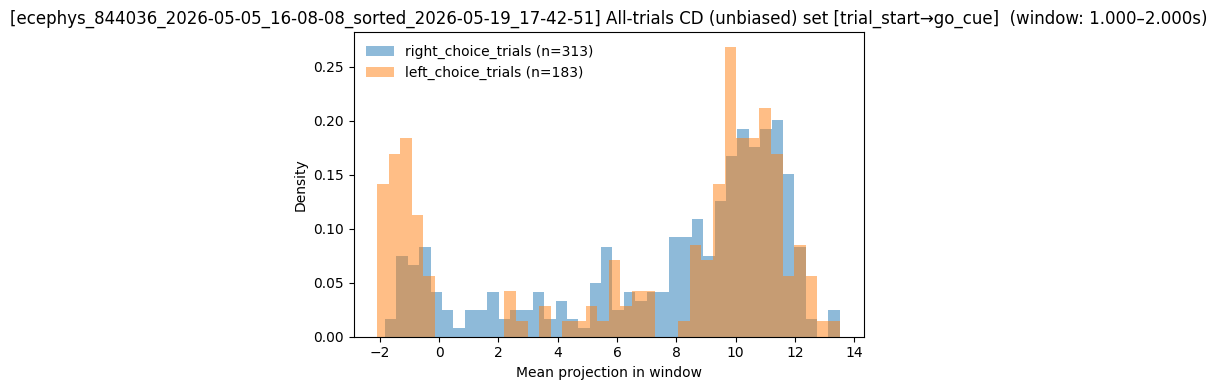


=== ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13: context-CD projected onto choice classes ===
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


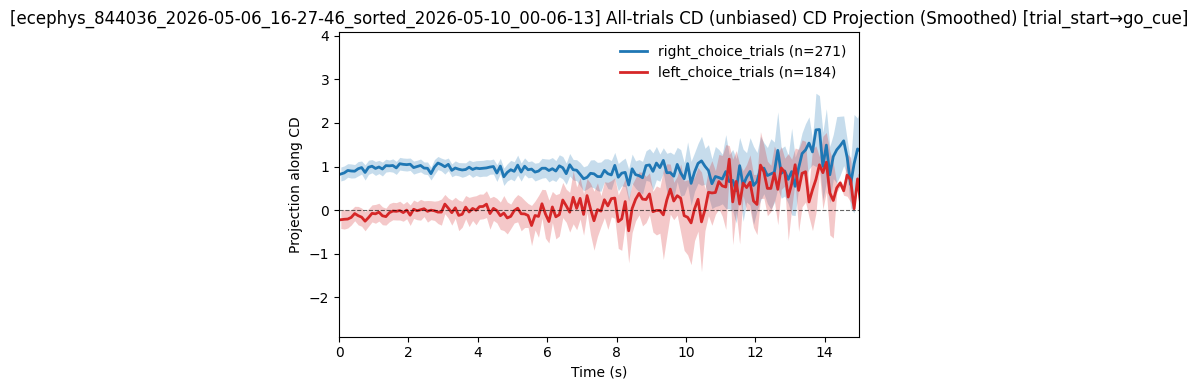

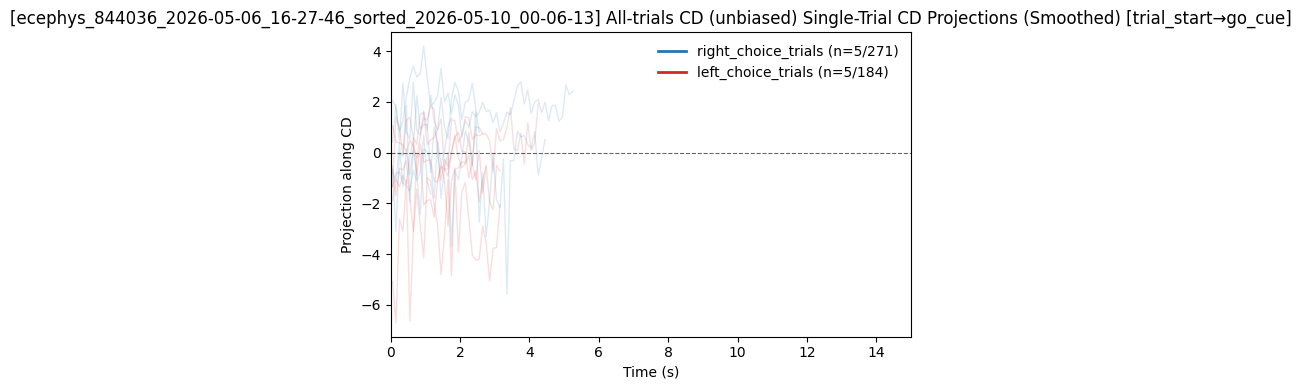

/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:75: RuntimeWarning: Mean of empty slice
  means = np.nanmean(sub, axis=1)


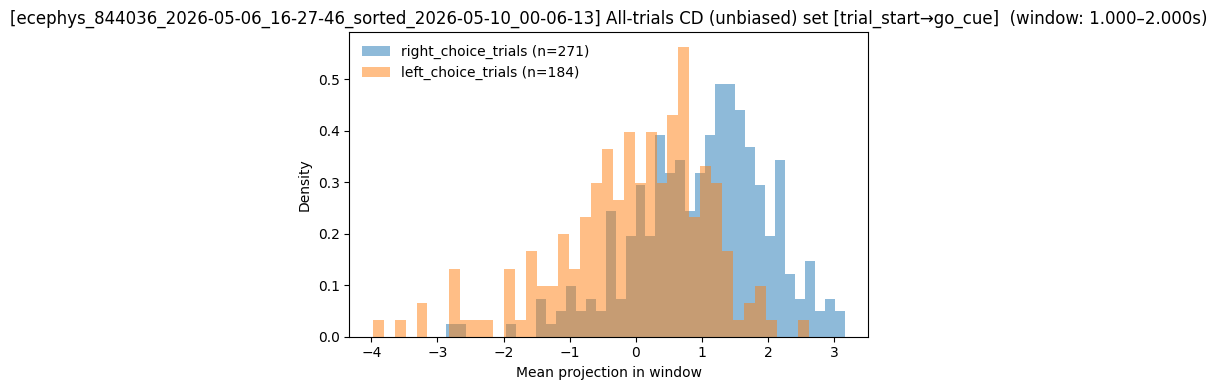

In [64]:
for session in sessions:
    zpath = cd_save_path(
        cd_root, session, region_lbl, context_trial_types, viz_time_window, align=align,
    )
    beh_csv = os.path.join(behavior_root, f"behavior_summary-{session}.csv")
    if not zpath.exists() or not os.path.exists(beh_csv):
        continue
    sess = load_cd_session(zpath, beh_csv)
    print(f"\n=== {session}: context-CD projected onto choice classes ===")
    plot_cd_session(
        sess,
        distribution_window=distribution_window,
        restrict_events=restrict_events,
        restrict_align=align,
        xlim=(0, 15),
        split="test",
        smooth_gauss=0.0,
        smooth_moving_window=5,
        plot_single_trial=True,
        random_sample_trial_N=5,
        trial_types=["right_choice_trials", "left_choice_trials"],
        #trial_types=["switch_LR_trials", "switch_RL_trials"],
    )

## Scatter: average CD projection vs P(right)

Each dot is a trial; x = sliding-window P(right) on that trial, y = mean CD projection over `scatter_window`. Highlighted trial types (e.g. `switch_LR_trials`, `switch_RL_trials`) are overlaid with distinct colors so structure tied to specific behavior categories stands out.

Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_pipeline.py:1691: RuntimeWarning: Mean of empty slice
  proj_mean = np.nanmean(sub, axis=1)


Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_pipeline.py:1691: RuntimeWarning: Mean of empty slice
  proj_mean = np.nanmean(sub, axis=1)


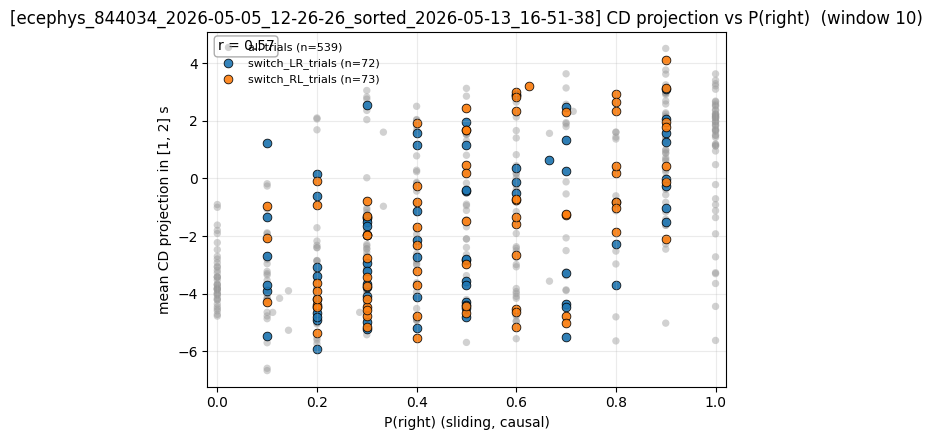

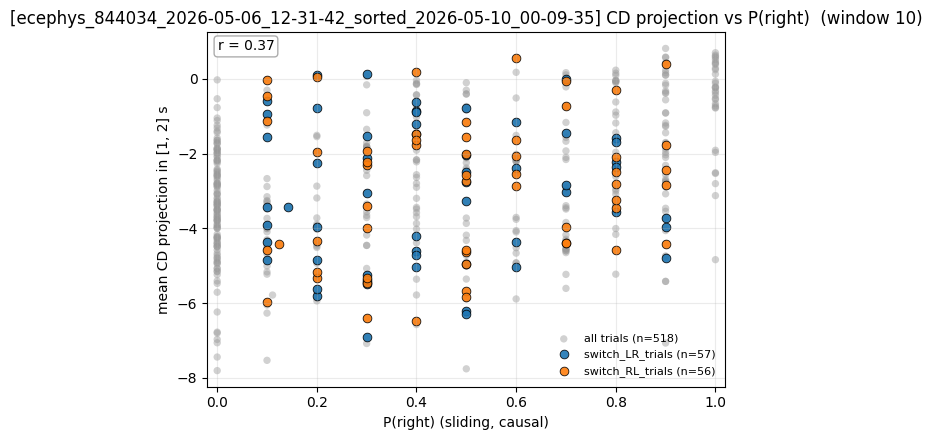

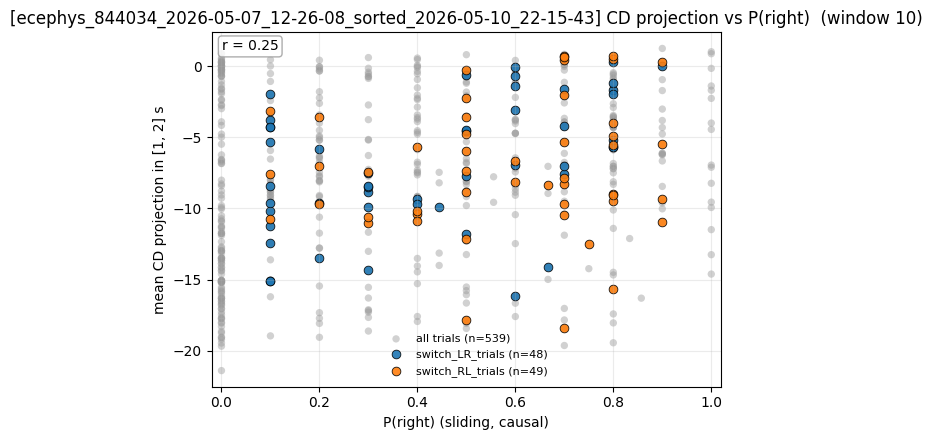

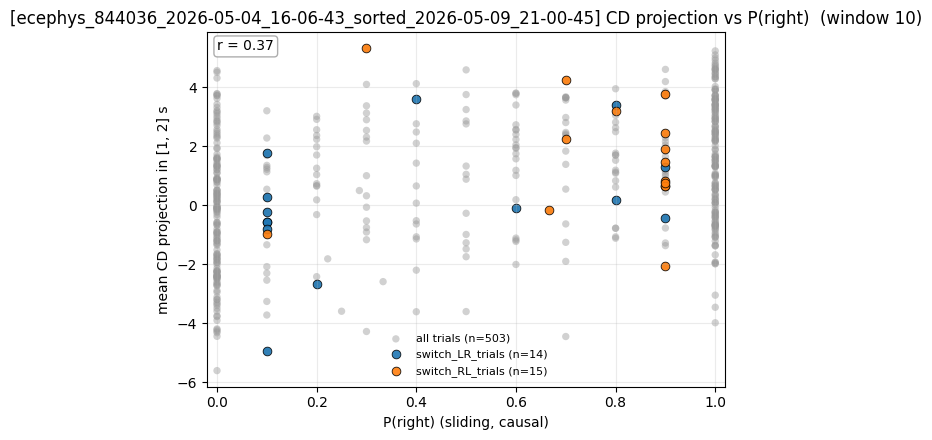

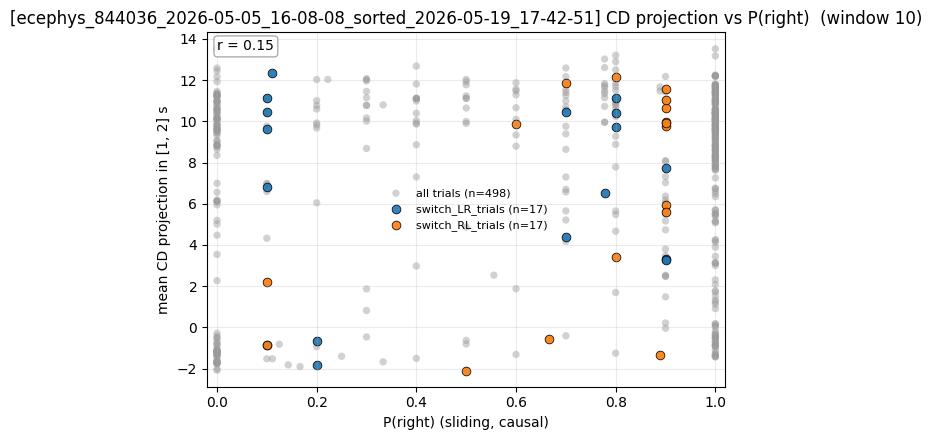

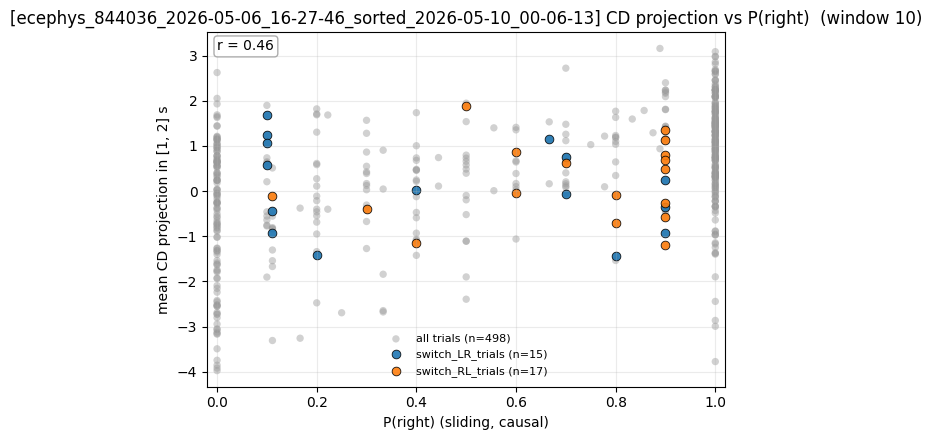

In [61]:
from ephys_dimension_reduction_CD_pipeline import (
    plot_cd_projection_vs_choice_probability,
)

scatter_window  = (1, 2)   # window (s) over which to average projection
p_right_window  = 10            # sliding-window length for P(right)
highlight_types = (
    "switch_LR_trials",
    "switch_RL_trials",
)

for session in sessions:
    zpath = cd_save_path(
        cd_root, session, region_lbl, context_trial_types, viz_time_window, align=align,
    )
    beh_csv = os.path.join(behavior_root, f"behavior_summary-{session}.csv")
    if not zpath.exists() or not os.path.exists(beh_csv):
        continue
    sess = load_cd_session(zpath, beh_csv)
    plot_cd_projection_vs_choice_probability(
        sess,
        window=scatter_window,
        p_right_window=p_right_window,
        highlight_trial_types=highlight_types,
        restrict_events=restrict_events,
        restrict_align=align,
    )

## Box plot: CD projection grouped by P(right)

Same data as the scatter, but trials are grouped by their P(right) bin and shown as box plots. The connecting line tracks the per-bin median across the P(right) axis.

Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_pipeline.py:1808: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_pipeline.py:1808: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_pipeline.py:1808: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_pipeline.py:1691: RuntimeWarning: Mean of empty slice
  proj_mean = np.nanmean(sub, axis=1)


Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_pipeline.py:1691: RuntimeWarning: Mean of empty slice
  proj_mean = np.nanmean(sub, axis=1)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_pipeline.py:1808: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


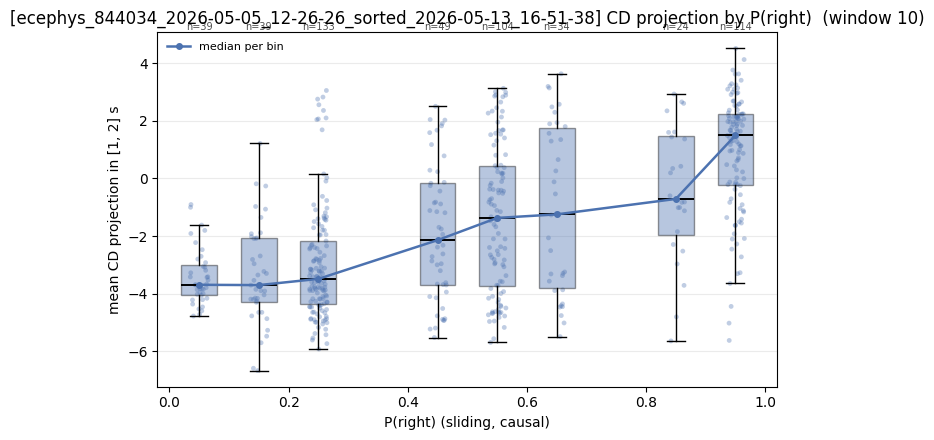

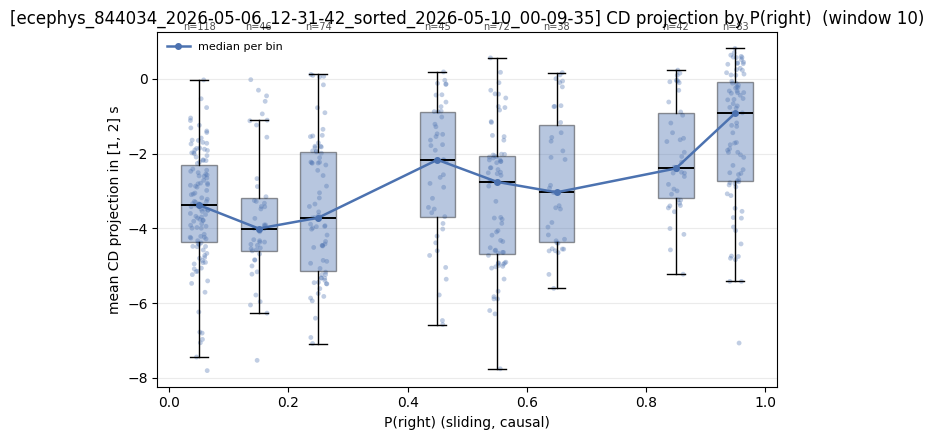

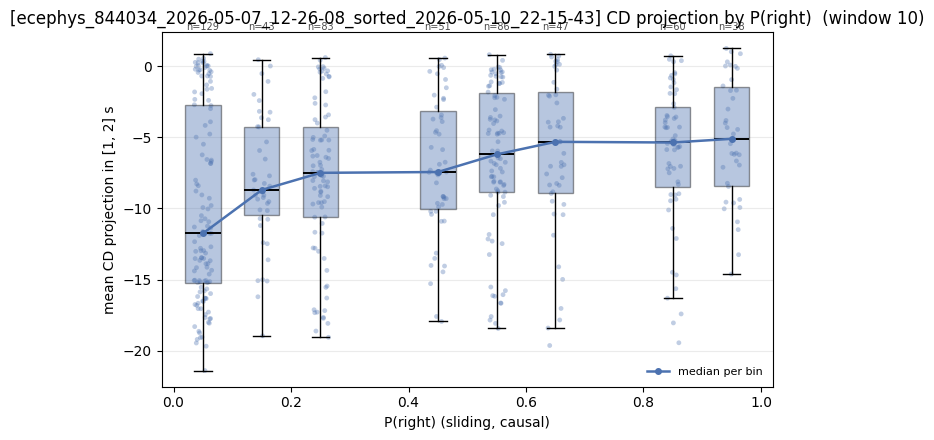

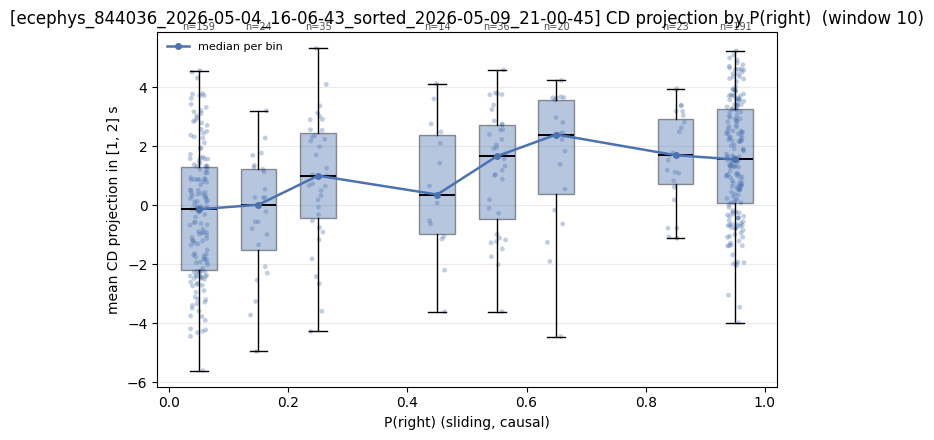

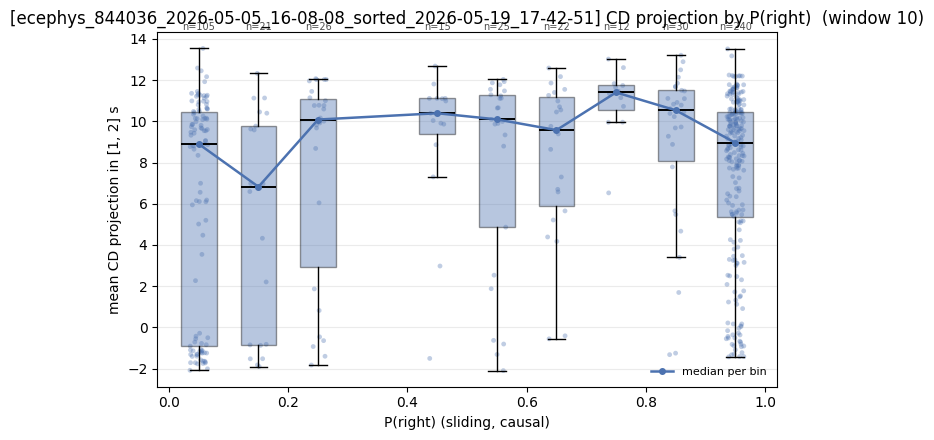

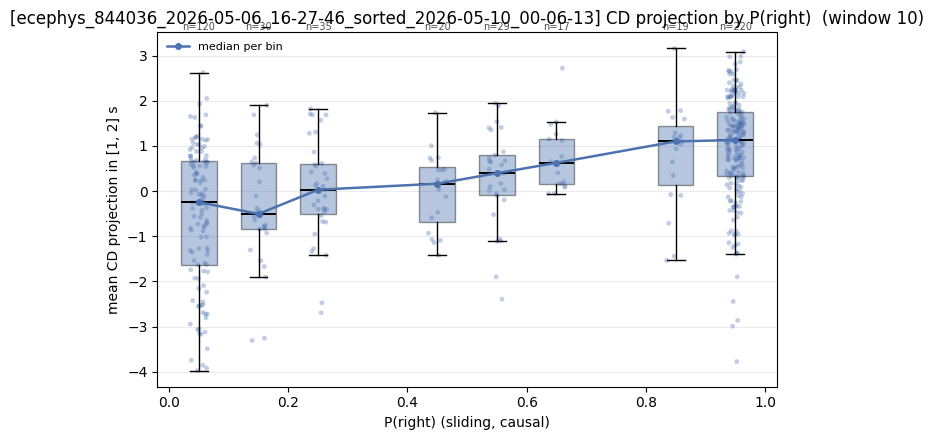

In [62]:
from ephys_dimension_reduction_CD_pipeline import (
    plot_cd_projection_box_by_choice_probability,
)
import numpy as np

highlight_types=[
    "switch_LR_trials",
    "switch_RL_trials"]

    
for session in sessions:
    zpath = cd_save_path(
        cd_root, session, region_lbl, context_trial_types, viz_time_window, align=align,
    )
    beh_csv = os.path.join(behavior_root, f"behavior_summary-{session}.csv")
    if not zpath.exists() or not os.path.exists(beh_csv):
        continue
    sess = load_cd_session(zpath, beh_csv)
    plot_cd_projection_box_by_choice_probability(
        sess,
        window=scatter_window,
        p_right_window=p_right_window,
        bins=np.linspace(0, 1, 11),  # uncomment for fixed-edge bins
        min_count=10,
        connect="median",
        show_scatter=True,
        #highlight_trial_types=highlight_types,
        restrict_events=restrict_events,
        restrict_align=align,
    )

## Box plot (combined across sessions)

Pool per-trial (P(right), CD-projection) pairs from every loaded session and render one combined box plot. Set `per_session_zscore=True` to compare *shapes* across sessions with different CD-projection scales (e.g. different unit counts).

Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_pipeline.py:1808: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_pipeline.py:1691: RuntimeWarning: Mean of empty slice
  proj_mean = np.nanmean(sub, axis=1)


Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb


{'positions': array([0.05, 0.15, 0.25, 0.45, 0.55, 0.65, 0.85, 0.95]),
 'data': [array([-2.13629144, -0.49990545, -4.17889637, -0.92403956,  1.52640682,
         -0.58790486]),
  array([-2.14755882, -1.12735692, -1.12271952, -0.77013427, -0.54624447,
         -0.8473937 ]),
  array([-1.93184804, -0.83910778,  0.08455134,  0.21341463,  2.71761669,
         -0.31157564]),
  array([-0.58850192,  0.71204812,  0.14176856, -0.42523048,  3.02371813,
         -0.17818157]),
  array([0.18279263, 0.12037497, 1.3796012 , 0.87093349, 2.72552062,
         0.05399535]),
  array([ 0.30627779, -0.15915973,  2.26504982,  1.60801911,  2.2052492 ,
          0.28384044]),
  array([0.84243206, 0.47841959, 2.21826692, 0.9073293 , 3.16912919,
         0.75787197]),
  array([3.05071755, 1.96136266, 2.47631454, 0.76383407, 1.59262098,
         0.7886798 ])],
 'counts': [6, 6, 6, 6, 6, 6, 6, 6],
 'labels': ['[0.00,0.10)',
  '[0.10,0.20)',
  '[0.20,0.30)',
  '[0.40,0.50)',
  '[0.50,0.60)',
  '[0.60,0.70)',
  '[0

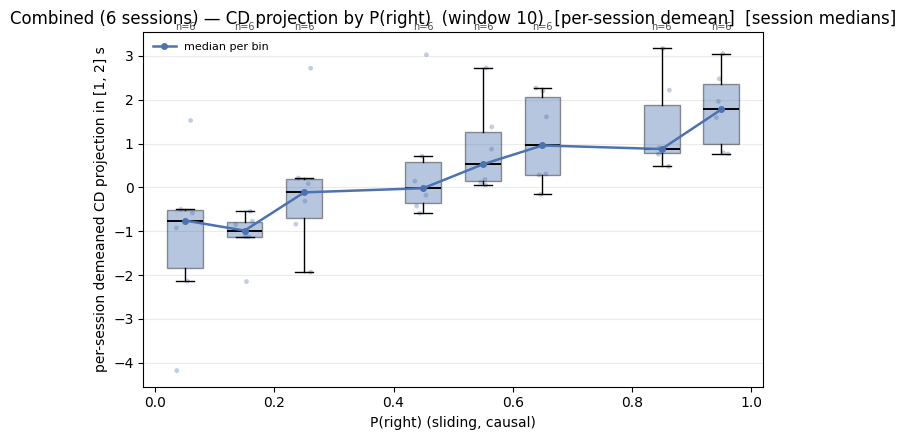

In [63]:
from ephys_dimension_reduction_CD_pipeline import (
    plot_cd_projection_box_by_choice_probability_combined,
)

# Load all sessions once so we can pool them.
sessions_data = []
for session in sessions:
    zpath = cd_save_path(
        cd_root, session, region_lbl, context_trial_types, viz_time_window, align=align,
    )
    beh_csv = os.path.join(behavior_root, f"behavior_summary-{session}.csv")
    if not zpath.exists() or not os.path.exists(beh_csv):
        continue
    sessions_data.append(load_cd_session(zpath, beh_csv))

plot_cd_projection_box_by_choice_probability_combined(
    sessions_data,
    window=scatter_window,
    p_right_window=p_right_window,
    bins=np.linspace(0, 1, 11),
    min_count=5,
    connect="median",
    show_scatter=True,
    session_normalize="demean",  # "none" | "demean" | "zscore" | "robust"
    highlight_trial_types=highlight_types,
    restrict_events=restrict_events,
    restrict_align=align,
    aggregate='session_medians'
)

## CD axis stability across time windows

For each session, refit the CD axis (class A vs class B) inside a series of
**non-overlapping** time windows tiling `[t_start, t_end]`. Each refit gives a
unit-norm axis vector in N-unit space. The pairwise **cosine similarity**
between those axis vectors quantifies how stable the population code is over
time: values near `+1` mean the same population direction encodes the contrast
throughout the window range, values near `0` mean orthogonal codes, and `−1`
mean a fully sign-flipped code.

Below we plot one heatmap per session, then an aggregate (mean across sessions
on the shared window grid).


In [89]:
from ephys_dimension_reduction_CD_pipeline import (
    compute_cd_stability_multi,
    plot_cd_stability,
)

# Non-overlapping CD-fit windows tiling [stab_t_start, stab_t_end] with width stab_bin_width.
stab_t_start    = 0    # seconds, relative to PSTH `align` (= go_cue here)
stab_t_end      =  7
stab_bin_width  =  0.2    # window width = step (no overlap)

# Trial contrast for the CD axis. Use the context contrast (default) or swap
# to e.g. ("right_choice_trials", "left_choice_trials") for choice CD.
stab_trial_types = context_trial_types

# Per-window trial eligibility: only fit on trials whose
# [restrict_events[0], restrict_events[1]] interval (offsets in the PSTH
# `align` frame) fully covers that window. Matches Section 5 of
# dimension_action_transition.ipynb. Set to None to disable.
stab_restrict_events = ("trial_start", "go_cue")
stab_restrict_align  = "trial_start"
align = "trial_start"

# When True, intersect eligible trials across every window so each CD axis is
# refit on the SAME trial set. This isolates temporal drift of the population
# code from drift driven by changing trial composition. Requires
# stab_restrict_events to be set; otherwise it's a no-op.
stab_use_common_trials = False

stab_results = compute_cd_stability_multi(
    sessions=sessions,
    psth_root=psth_root,
    behavior_root=behavior_root,
    trial_types=stab_trial_types,
    align=align,
    binsize=binsize,
    t_start=stab_t_start,
    t_end=stab_t_end,
    bin_width=stab_bin_width,
    metadata=None,                # all units
    restrict_events=stab_restrict_events,
    restrict_align=stab_restrict_align,
    use_common_trials=stab_use_common_trials,
    norm_mode=norm_mode,
    zscore_units=False,
    random_state=random_state,
    verbose=True,
)
print(f"\n{len(stab_results)} session(s) succeeded.")


[ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38] CD stability: 35 windows, |A|=114, |B|=78, units=ALL
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
  restrict_events=('trial_start', 'go_cue'): 539 trials have valid offsets.
[ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35] CD stability: 35 windows, |A|=83, |B|=164, units=ALL
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
  restrict_events=('trial_start', 'go_cue'): 518 trials have valid offsets.
[ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43] CD stability: 35 windows, |A|=40, |B|=172, units=ALL
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Successfully read behavior NWB from: /root/capsu

In [90]:
# Per-window trial-count diagnostic — helps spot bins where the CD axis is
# fit on too few trials (sign flips / noisy cosines often come from here).
# Each row of the printed DataFrame is one bin center; columns are
# n_eligible, n_A, n_B for each session.
import pandas as pd
import numpy as np

rows = []
for s, r in stab_results.items():
    for c, ne, na, nb in zip(
        r["centers"],
        r["per_window_n_eligible"],
        r["per_window_n_A"],
        r["per_window_n_B"],
    ):
        rows.append({"session": s, "center": float(c),
                     "n_eligible": int(ne), "n_A": int(na), "n_B": int(nb)})
diag_df = pd.DataFrame(rows)

# Summary across sessions: min / median trials per class at each bin.
summary = (
    diag_df.groupby("center")[["n_A", "n_B"]]
    .agg(["min", "median"])
    .round(1)
)
print("Trials per class per bin (across sessions):")
print(summary.to_string())

# Flag bins where any session falls below a usable count.
MIN_TRIALS = 10
bad_centers = (
    diag_df.groupby("center")[["n_A", "n_B"]].min()
    .min(axis=1)
    .pipe(lambda s: s[s < MIN_TRIALS].index.tolist())
)
if bad_centers:
    print(f"\n[warn] {len(bad_centers)} bins where min(n_A, n_B) < {MIN_TRIALS} in at least one session:")
    print(np.round(bad_centers, 3).tolist())
else:
    print(f"\nAll bins have >= {MIN_TRIALS} trials in every class & session.")


Trials per class per bin (across sessions):
       n_A        n_B       
       min median min median
center                      
0.1     40  152.5  78  157.5
0.3     40  152.5  78  157.5
0.5     40  152.5  78  157.5
0.7     40  152.5  78  157.5
0.9     40  152.5  78  157.5
1.1     40  152.5  78  156.0
1.3     40  152.5  78  156.0
1.5     40  152.5  78  155.0
1.7     40  152.5  78  154.5
1.9     40  151.0  78  154.0
2.1     36  141.5  73  145.5
2.3     32  133.0  66  135.5
2.5     27  126.5  60  129.0
2.7     24  120.0  58  121.5
2.9     23  115.0  56  110.5
3.1     21  111.5  52  103.0
3.3     19  107.0  46   94.0
3.5     19  100.0  44   88.5
3.7     17   96.0  41   79.0
3.9     14   90.5  37   75.5
4.1     14   83.5  33   70.5
4.3     13   77.5  30   65.0
4.5     12   74.0  28   63.0
4.7     12   69.0  24   61.0
4.9     11   65.5  24   56.5
5.1     11   60.5  23   52.0
5.3     10   58.0  22   47.5
5.5      8   53.5  21   44.5
5.7      8   50.5  18   43.5
5.9      7   47.0  16   41.5

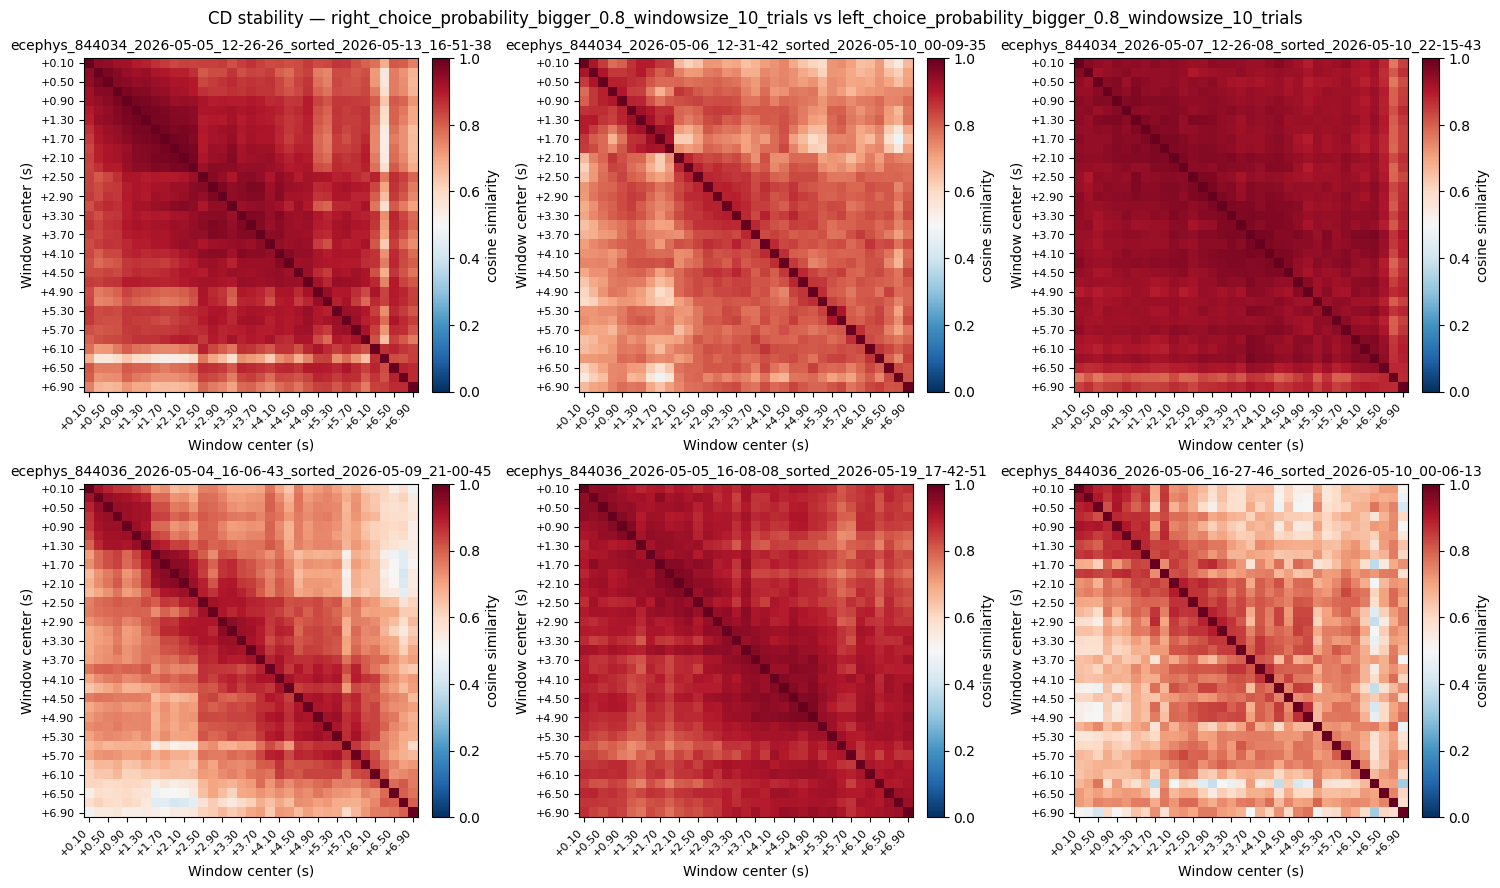

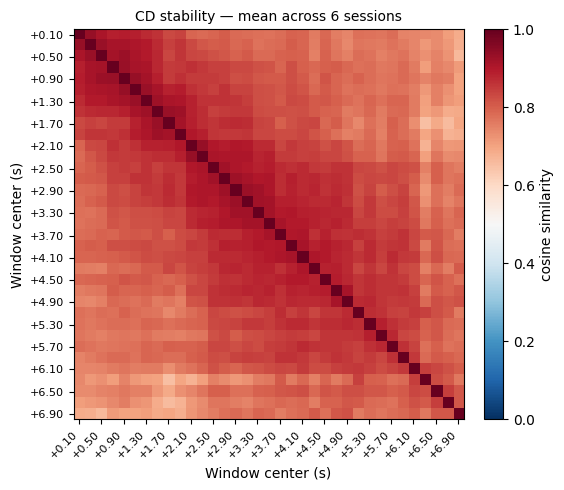

In [91]:
# Per-session heatmaps (one panel per session)
plot_cd_stability(
    stab_results,
    cmap="RdBu_r",
    vmin=0, vmax=1.0,
    annotate_centers=True,
    title=f"CD stability — {stab_trial_types[0]} vs {stab_trial_types[1]}",
)

# Mean cosine across sessions (sessions share the same window grid here).
plot_cd_stability(
    stab_results,
    aggregate=True,
    cmap="RdBu_r",
    vmin=-0, vmax=1.0,
    title=f"CD stability — mean across {len(stab_results)} sessions",
)


## Single-trial CD-projection heatmaps

For each session, render the per-trial context-CD projection as a 2-D heatmap
(one row per trial, one panel per class). Trials are aligned to
`trial_start`, masked to their `[trial_start, go_cue]` interval, and sorted
within each panel by window length so the staircase makes long-ITI trials
visible at the top.


In [103]:
zpath

PosixPath('/root/capsule/scratch/CD_results/CD_ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13_RG_ALL_right_choice_probability_bigger_0.8_windowsize_10_trials_left_choice_probability_bigger_0.8_windowsize_10_trials_TW_1_2_ALIGN_trial_start.zarr')

Single-trial heatmaps | region=RG_ALL (ALL) | TW=(1, 2) | align=trial_start

=== Session: ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38 ===
File: CD_ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38_RG_ALL_right_choice_probability_bigger_0.8_windowsize_10_trials_left_choice_probability_bigger_0.8_windowsize_10_trials_TW_1_2_ALIGN_trial_start.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb


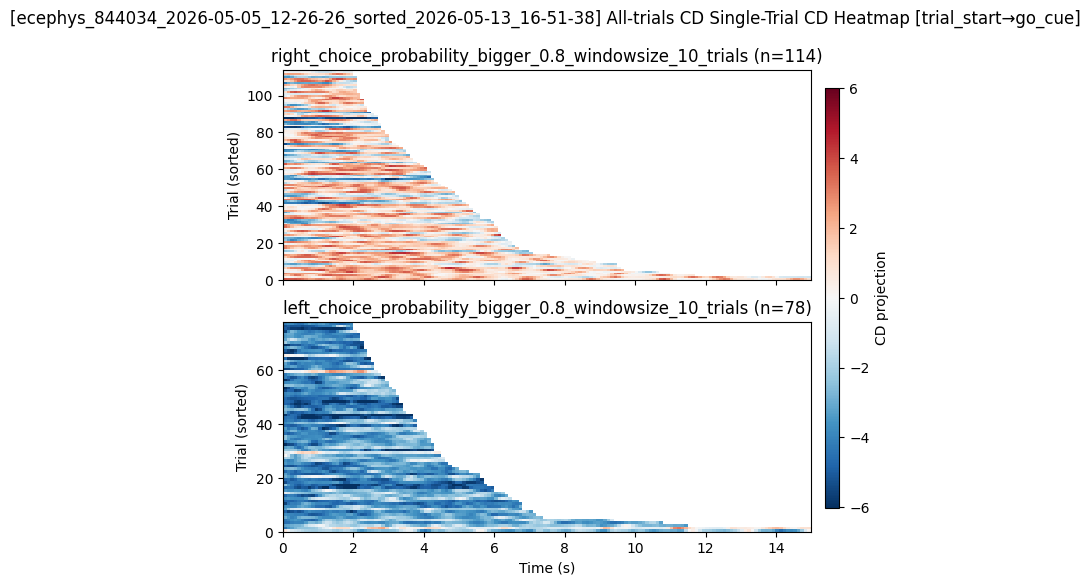


=== Session: ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35 ===
File: CD_ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35_RG_ALL_right_choice_probability_bigger_0.8_windowsize_10_trials_left_choice_probability_bigger_0.8_windowsize_10_trials_TW_1_2_ALIGN_trial_start.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb


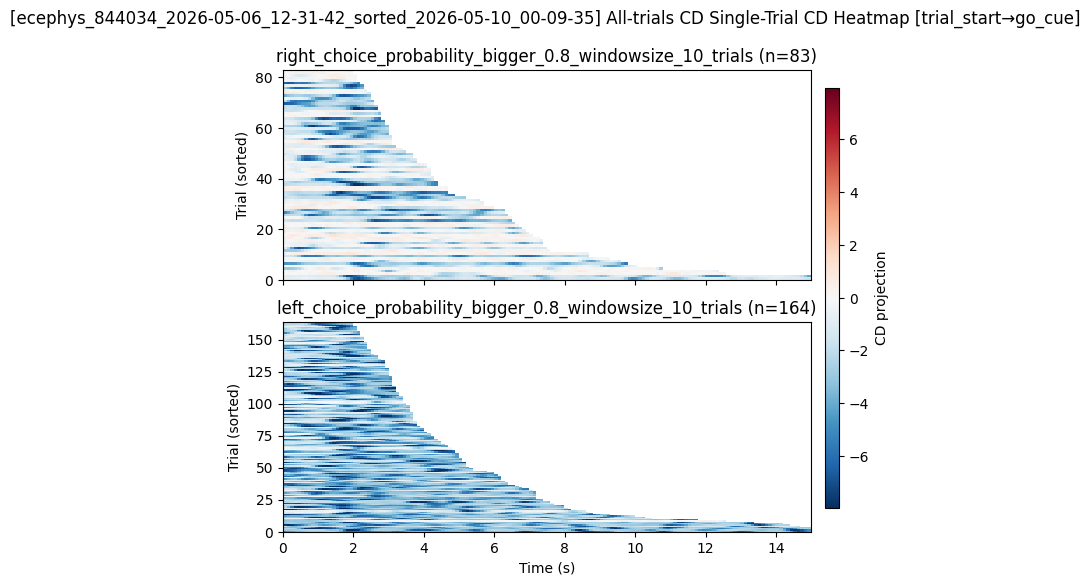


=== Session: ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43 ===
File: CD_ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43_RG_ALL_right_choice_probability_bigger_0.8_windowsize_10_trials_left_choice_probability_bigger_0.8_windowsize_10_trials_TW_1_2_ALIGN_trial_start.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb


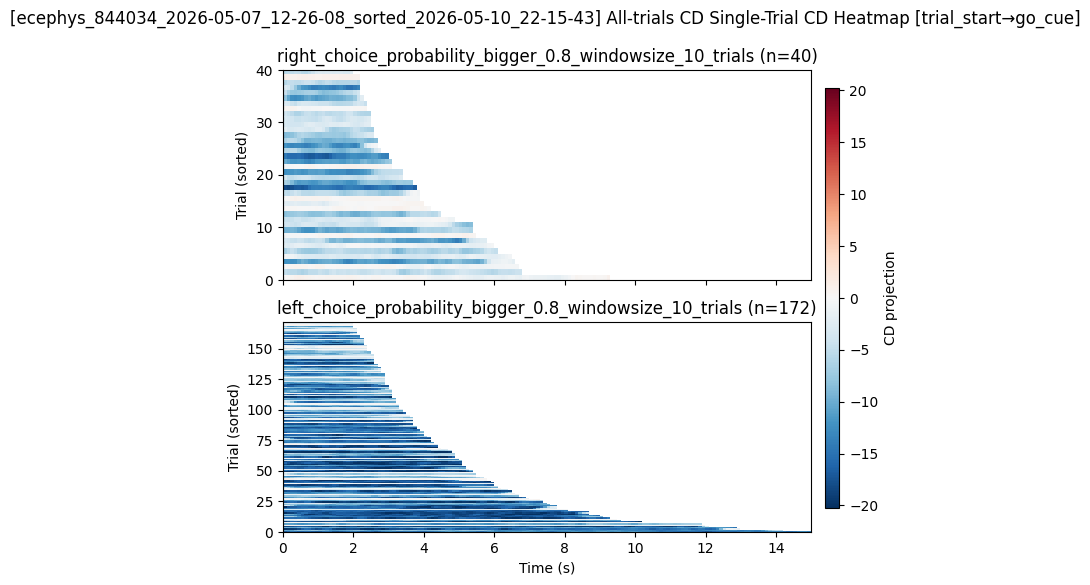


=== Session: ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45 ===
File: CD_ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45_RG_ALL_right_choice_probability_bigger_0.8_windowsize_10_trials_left_choice_probability_bigger_0.8_windowsize_10_trials_TW_1_2_ALIGN_trial_start.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb


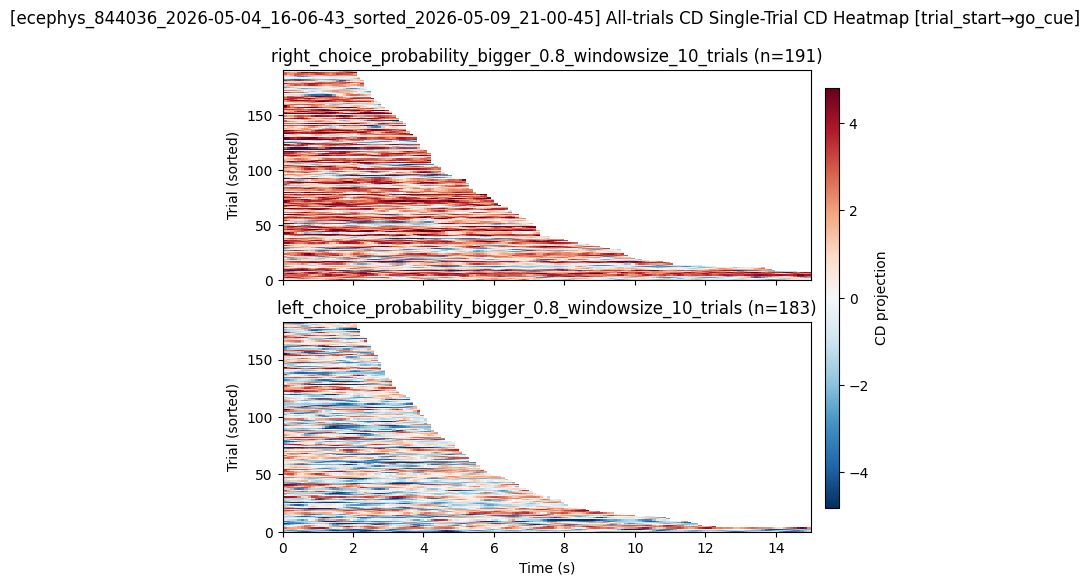


=== Session: ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51 ===
File: CD_ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51_RG_ALL_right_choice_probability_bigger_0.8_windowsize_10_trials_left_choice_probability_bigger_0.8_windowsize_10_trials_TW_1_2_ALIGN_trial_start.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb


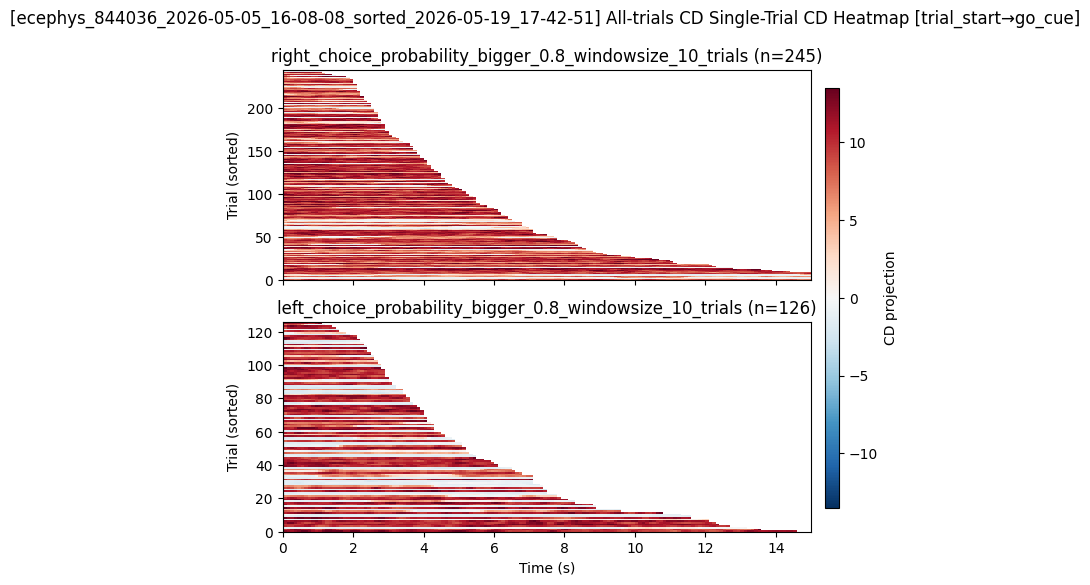


=== Session: ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13 ===
File: CD_ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13_RG_ALL_right_choice_probability_bigger_0.8_windowsize_10_trials_left_choice_probability_bigger_0.8_windowsize_10_trials_TW_1_2_ALIGN_trial_start.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb


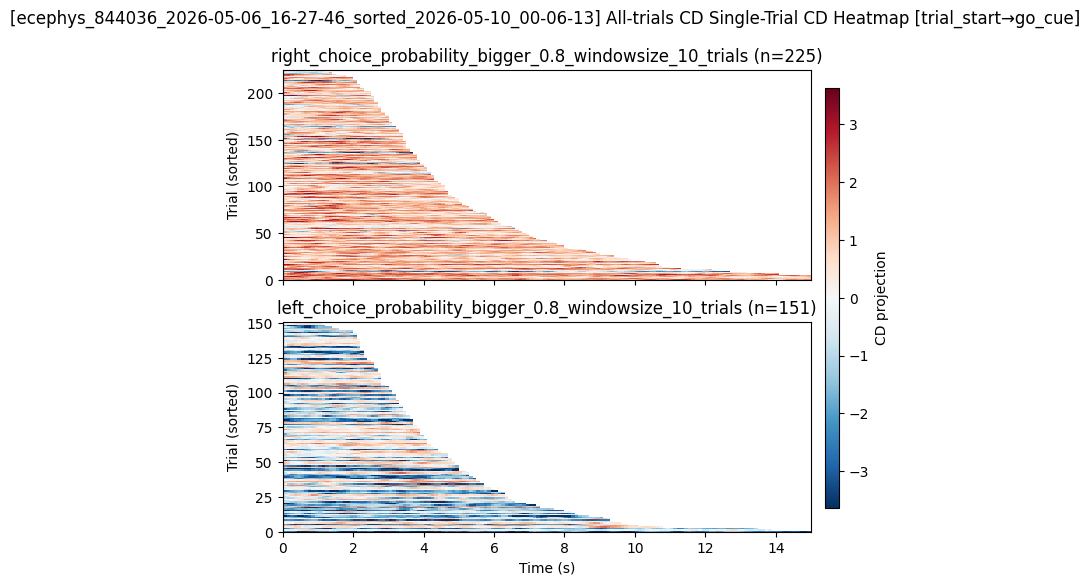

In [102]:
import os
from ephys_dimension_reduction_CD_pipeline import (
    cd_save_path, load_cd_session, plot_cd_session_heatmap, region_label,
)

# Match the CD zarrs built earlier in this notebook (context trial types,
# all units, TW=(1,2), align="trial_start").
hm_region_group   = []
hm_time_window    = (1, 2)
hm_trial_types    = context_trial_types
hm_restrict_events = ("trial_start", "go_cue")
hm_restrict_align  = "trial_start"

# Color-limit quantile. Lower => higher contrast (more outlier clipping).
hm_vrange_quantile = 0.99

region_lbl, region_print = region_label(hm_region_group)
print(f"Single-trial heatmaps | region={region_lbl} ({region_print}) | "
      f"TW={hm_time_window} | align={align}")

for session in sessions:
    zpath = cd_save_path(
        cd_root, session, region_lbl, hm_trial_types, hm_time_window, align=align,
    )
    beh_csv = os.path.join(behavior_root, f"behavior_summary-{session}.csv")
    if not zpath.exists():
        print(f"[skip] CD zarr not found: {zpath}")
        continue
    if not os.path.exists(beh_csv):
        print(f"[skip] behavior CSV not found for {session}")
        continue

    print(f"\n=== Session: {session} ===\nFile: {zpath.name}")
    sess = load_cd_session(zpath, beh_csv)

    plot_cd_session_heatmap(
        sess,
        trial_types=list(hm_trial_types),
        smooth_gauss=0.1,
        sort_by="window_length",
        sort_window=(0, 15),
        xlim=(0, 15),
        cmap="RdBu_r",
        symmetric_colorbar=True,
        vrange_quantile=hm_vrange_quantile,
        restrict_events=hm_restrict_events,
        restrict_align=hm_restrict_align,
    )


## Single-trial dwell metrics (persistency index)

For each trial we measure how persistently the single-trial CD projection
stays on its own context side within `dwell_time_window`. The headline
metric is the **persistency index** in `[-1, +1]`:

- `+1` â†’ every (non-deadband) sample is on the trial's own-class side
- `-1` â†’ every (non-deadband) sample is on the *other* class's side
- `0`  â†’ time on either side is equal

Auxiliary metrics (also returned per trial): `frac_on_class`,
`frac_off_class`, `longest_run_on_class_sec`, `longest_run_off_class_sec`,
`mean_signed_distance_on_class`, `mean_sign`, `n_sign_changes`, plus
raw-projection summaries (`mean_projection`, `mean_abs_projection`, etc).
`center` defaults to `0`; set it to `"cross_class_median"` to use a
data-driven decision boundary instead.


In [10]:
import os
from ephys_dimension_reduction_CD_pipeline import (
    cd_save_path, load_cd_session, compute_cd_dwell_metrics_multi, region_label,
)

# Match the CD zarrs built earlier in this notebook.
dwell_region_group   = []
dwell_time_window_cd = (1, 2)   # CD-fit window used when building the zarr
dwell_trial_types    = context_trial_types

# Scoring window (in restrict_align frame) and per-trial eligibility.
dwell_time_window     = (0, 15)
dwell_restrict_events = ("trial_start", "go_cue")
dwell_restrict_align  = "trial_start"

align='trial_start'

# Scoring parameters.
dwell_smooth_gauss = 0.1                  # gaussian smoothing (s) before scoring
dwell_center       = "cross_class_median" # 0.0 or "cross_class_median"
dwell_deadband     = 0.0                  # |x - center| < deadband => ambiguous
# Map class index -> expected sign on the CD axis. Default (+1, -1).
dwell_class_signs  = (1, -1)

dwell_region_lbl, dwell_region_print = region_label(dwell_region_group)
print(f"Dwell metrics | region={dwell_region_lbl} ({dwell_region_print}) | "
      f"TW={dwell_time_window_cd} | align={align}")



# Load CD sessions whose zarrs were built earlier.
dwell_sessions_data = []
for session in sessions:
    zpath = cd_save_path(
        cd_root, session, dwell_region_lbl, dwell_trial_types,
        dwell_time_window_cd, align=align,
    )
    beh_csv = os.path.join(behavior_root, f"behavior_summary-{session}.csv")
    if not zpath.exists():
        print(f"[skip] CD zarr not found: {zpath}")
        continue
    if not os.path.exists(beh_csv):
        print(f"[skip] behavior CSV not found for {session}")
        continue
    dwell_sessions_data.append(load_cd_session(zpath, beh_csv))

print(f"Loaded {len(dwell_sessions_data)} session(s) for dwell scoring.")

dwell_df = compute_cd_dwell_metrics_multi(
    dwell_sessions_data,
    trial_types=list(dwell_trial_types),
    time_window=dwell_time_window,
    restrict_events=dwell_restrict_events,
    restrict_align=dwell_restrict_align,
    smooth_gauss=dwell_smooth_gauss,
    smooth_mode="gaussian",
    projection_source="unbiased",
    center=dwell_center,
    deadband=dwell_deadband,
    class_signs=dwell_class_signs,
)
print(f"\nTotal trials scored: {len(dwell_df)}")
dwell_df.head()


Dwell metrics | region=RG_ALL (ALL) | TW=(1, 2) | align=trial_start
Loaded 6 session(s) for dwell scoring.
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_20

,session,trial_id,class_name,class_index,class_sign,t_start,t_end,center,deadband,valid_duration_sec,...,mean_sign,n_sign_changes,longest_run_pos_sec,longest_run_neg_sec,frac_on_class,frac_off_class,mean_signed_distance_on_class,longest_run_on_class_sec,longest_run_off_class_sec,persistency_index
0,ecephys_844034_2026-05-05_12-26-26_sorted_2026...,0,right_choice_probability_bigger_0.8_windowsize...,0,1,0.0,15.0,-0.672384,0.0,5.6,...,0.750000,1,4.9,0.7,0.875000,0.125000,1.753619,4.9,0.7,0.750000
1,ecephys_844034_2026-05-05_12-26-26_sorted_2026...,12,right_choice_probability_bigger_0.8_windowsize...,0,1,0.0,15.0,-0.672384,0.0,15.0,...,0.746667,7,7.7,0.9,0.873333,0.126667,1.916874,7.7,0.9,0.746667
2,ecephys_844034_2026-05-05_12-26-26_sorted_2026...,13,right_choice_probability_bigger_0.8_windowsize...,0,1,0.0,15.0,-0.672384,0.0,4.8,...,0.875000,3,4.4,0.2,0.937500,0.062500,2.080095,4.4,0.2,0.875000
3,ecephys_844034_2026-05-05_12-26-26_sorted_2026...,14,right_choice_probability_bigger_0.8_windowsize...,0,1,0.0,15.0,-0.672384,0.0,9.5,...,0.705263,3,5.4,1.0,0.852632,0.147368,1.359362,5.4,1.0,0.705263
4,ecephys_844034_2026-05-05_12-26-26_sorted_2026...,15,right_choice_probability_bigger_0.8_windowsize...,0,1,0.0,15.0,-0.672384,0.0,6.5,...,0.907692,4,5.6,0.2,0.953846,0.046154,1.674618,5.6,0.2,0.907692


In [11]:
# Per-class summary across sessions + persistency-index distribution.
import numpy as np
import matplotlib.pyplot as plt

if dwell_df.empty:
    print("No dwell metrics computed.")
else:
    summary_cols = [
        "persistency_index", "frac_on_class", "longest_run_on_class_sec",
        "mean_signed_distance_on_class", "n_sign_changes",
        "valid_duration_sec",
    ]
    print("Per-class summary (median [Q25, Q75], pooled across sessions):\n")
    grp = dwell_df.groupby("class_name")[summary_cols]
    summary = grp.agg(
        median="median",
        q25=lambda s: s.quantile(0.25),
        q75=lambda s: s.quantile(0.75),
        n="count",
    )
    print(summary.round(3).to_string())

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    bins = np.linspace(-1, 1, 41)
    classes = list(dwell_df["class_name"].unique())
    colors = {c: f"C{i}" for i, c in enumerate(classes)}

    ax = axes[0]
    for c in classes:
        vals = dwell_df.loc[dwell_df["class_name"] == c, "persistency_index"].dropna()
        ax.hist(vals, bins=bins, alpha=0.5, label=f"{c} (n={vals.size})", color=colors[c])
        ax.axvline(float(vals.median()), color=colors[c], ls="--", lw=1.5)
    ax.axvline(0, color="k", lw=0.8, alpha=0.5)
    ax.set_xlabel("persistency_index")
    ax.set_ylabel("# trials")
    ax.set_title("Persistency index by class")
    ax.legend(loc="best", fontsize=9)

    ax = axes[1]
    # Per-session median persistency_index, color-coded by class.
    per_sess = (
        dwell_df.groupby(["session", "class_name"])["persistency_index"]
        .median().reset_index()
    )
    for c in classes:
        sub = per_sess[per_sess["class_name"] == c]
        ax.scatter(np.arange(len(sub)), sub["persistency_index"],
                   color=colors[c], label=c, s=40)
    ax.axhline(0, color="k", lw=0.8, alpha=0.5)
    ax.set_ylim(-1, 1)
    ax.set_xlabel("session index")
    ax.set_ylabel("median persistency_index")
    ax.set_title("Per-session median persistency_index")
    ax.legend(loc="best", fontsize=9)

    fig.tight_layout()
    plt.show()


Per-class summary (median [Q25, Q75], pooled across sessions):



TypeError: Must provide 'func' or tuples of '(column, aggfunc).